In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Libraries**

In [2]:
import numpy as np

In [3]:
!pip install rasterio
!pip install matplotlib  # Optional for visualization

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 104.1 MB/s eta 0:00:00


In [4]:
!pip install dbfread

In [5]:
pip install imagecodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 95.2 MB/s eta 0:00:00


In [6]:
!pip install rasterio numpy opencv-python pillow tqdm

# **Rasterize**

In [22]:
# Class → ID mapping
class_map = {
    'background': 0,
    'builtup': 1,
    'grassland': 2,
    'bare land': 3,
    'forest': 4,
    'shrubland': 5,
    'water body': 6,
    'wetland': 7,
    'permanent ice and snow': 8,
    'other crop': 9,
    'flower seeds': 10,
    'orchards': 11,
    'maize': 12,
    'wheat': 13,
    'rice': 14
}

Raster CRS: EPSG:4326
Raster bounds: BoundingBox(left=105.81713872438745, bottom=30.349671705506445, right=106.43805424877087, top=30.97058722988986)
Shapefile CRS: EPSG:4326
Shapefile bounds: [105.9181897   30.349955   106.433099    30.93622643]
Unique mapped class IDs: [ 9 14 11 10  4  7  1]
✅ Raster mask saved: /content/drive/MyDrive/Padded_masks (1)/BM09_01.tif
Classes in mask: [ 0  1  4  7  9 10 11 14]


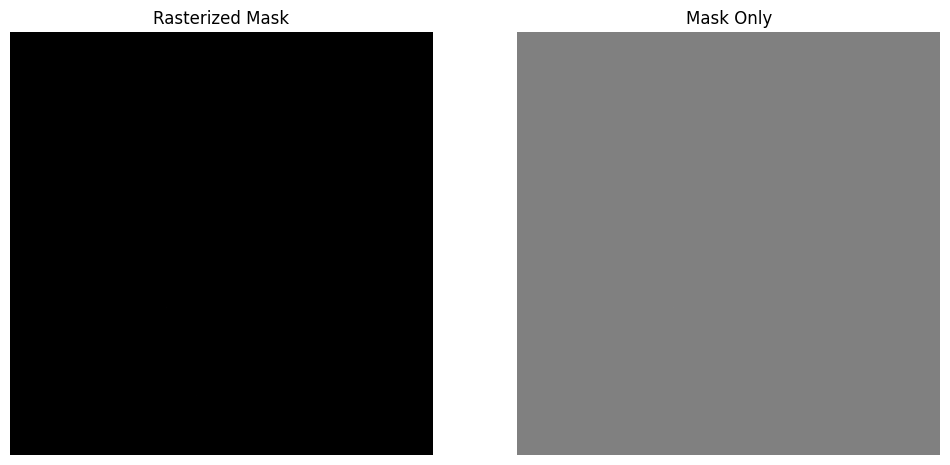

In [32]:
import os
import rasterio
from rasterio import features
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# === Input paths ===
image_path  = "/content/drive/MyDrive/Images/BM09_01.tif"
shapefile_path = "/content/drive/MyDrive/Masks/BM09_01.shp"
output_path = "/content/drive/MyDrive/Padded_masks (1)/BM09_01.tif"

# === Class map ===
class_map = {
    'background': 0, 'builtup': 1, 'grassland': 2, 'bare land': 3, 'forest': 4,
    'shrubland': 5, 'water body': 6, 'wetland': 7, 'permanent ice and snow': 8,
    'other crop': 9, 'flower seeds': 10, 'orchards': 11, 'maize': 12,
    'wheat': 13, 'rice': 14
}

# === 1. Read raster ===
with rasterio.open(image_path) as src:
    ref_meta = src.meta.copy()
    ref_crs = src.crs
    ref_transform = src.transform
    ref_shape = (src.height, src.width)
    print("Raster CRS:", ref_crs)
    print("Raster bounds:", src.bounds)

# === 2. Read shapefile ===
gdf = gpd.read_file(shapefile_path)
print("Shapefile CRS:", gdf.crs)
print("Shapefile bounds:", gdf.total_bounds)

# --- Reproject shapefile to raster CRS if needed ---
if gdf.crs != ref_crs:
    print("⚠️ CRS mismatch, reprojecting shapefile...")
    gdf = gdf.to_crs(ref_crs)

# --- Map classes to IDs ---
if "Classes" not in gdf.columns:
    raise ValueError("No 'Classes' column found in shapefile!")

gdf["class_id"] = gdf["Classes"].str.lower().map(class_map)
print("Unique mapped class IDs:", gdf["class_id"].unique())

# Drop missing
gdf = gdf.dropna(subset=["class_id"])
gdf["class_id"] = gdf["class_id"].astype(np.uint8)

# === 3. Rasterize ===
shapes = ((geom, val) for geom, val in zip(gdf.geometry, gdf["class_id"]))
mask = features.rasterize(
    shapes=shapes,
    out_shape=ref_shape,
    transform=ref_transform,
    fill=0,
    dtype="uint8"
)

# === 4. Save mask ===
mask_meta = ref_meta.copy()
mask_meta.update({"count": 1, "dtype": "uint8"})
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with rasterio.open(output_path, "w", **mask_meta) as dst:
    dst.write(mask, 1)

print(" Raster mask saved:", output_path)
print("Classes in mask:", np.unique(mask))

# === 5. Quick visualization ===
cmap = ListedColormap([ '#000000','#ff0000','#7CFC00','#e5c07b','#013220',
                        '#BDB76B','#4a90e2','#76d7c4','#ffffff','#e6e600',
                        '#ff69b4','#228B22','#ffd700','#c2b280','#ffffff'])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(mask, cmap=cmap, vmin=0, vmax=14)
plt.title("Rasterized Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap=cmap, vmin=0, vmax=14, alpha=0.5)
plt.title("Mask Only")
plt.axis("off")
plt.show()


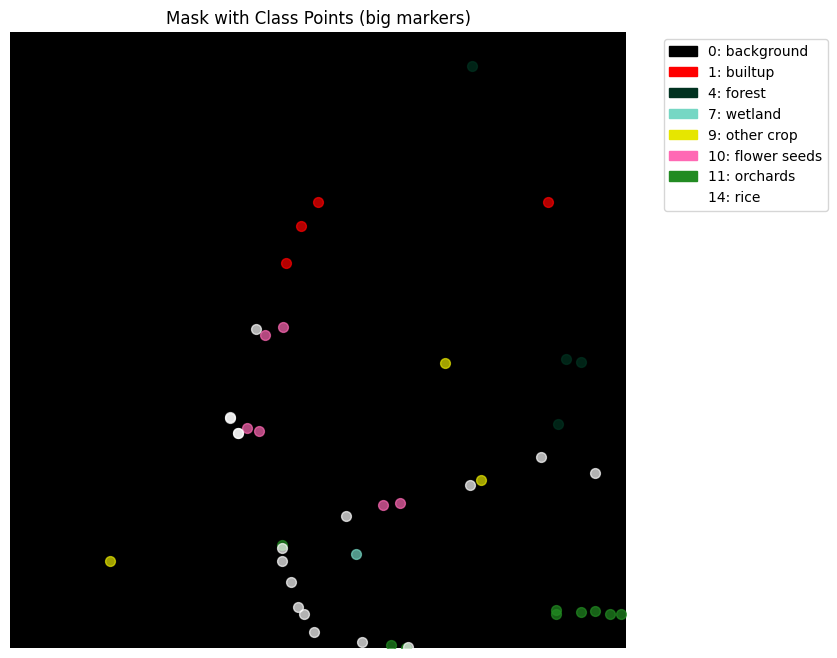

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# === Assume you already have your mask array ===
# mask = ...

classes_with_ids = [
    (0, 'background'),
    (1, 'builtup'),
    (2, 'grassland'),
    (3, 'bare land'),
    (4, 'forest'),
    (5, 'shrubland'),
    (6, 'water body'),
    (7, 'wetland'),
    (8, 'permanent ice and snow'),
    (9, 'other crop'),
    (10, 'flower seeds'),
    (11, 'orchards'),
    (12, 'maize'),
    (13, 'wheat'),
    (14, 'rice')
]

color_map = {
    0:  '#000000',
    1:  '#ff0000',
    2:  '#7CFC00',
    3:  '#e5c07b',
    4:  '#013220',
    5:  '#BDB76B',
    6:  '#4a90e2',
    7:  '#76d7c4',
    8:  '#ffffff',
    9:  '#e6e600',
    10: '#ff69b4',
    11: '#228B22',
    12: '#ffd700',
    13: '#c2b280',
    14: '#ffffff',
}

# --- Plot ---
plt.figure(figsize=(8,8))
plt.imshow(np.zeros_like(mask), cmap="gray")  # empty background

for class_id, name in classes_with_ids:
    ys, xs = np.where(mask == class_id)
    if len(xs) > 0 and class_id != 0:  # skip background
        plt.scatter(xs, ys, s=50, c=color_map[class_id], label=f"{class_id}: {name}", alpha=0.7)

# Legend
handles = [mpatches.Patch(color=color_map[i], label=f"{i}: {name}")
           for i, name in classes_with_ids if i in np.unique(mask)]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Mask with Class Points (big markers)")
plt.axis("off")
plt.show()


rasterize all

In [37]:
import os
import rasterio
from rasterio import features
import geopandas as gpd
import numpy as np
from glob import glob
from tqdm import tqdm   #  progress bar

# === Input directories ===
image_dir     = "/content/drive/MyDrive/Images"
shapefile_dir = "/content/drive/MyDrive/Masks"
output_dir    = "/content/drive/MyDrive/Raster_masks_all"

os.makedirs(output_dir, exist_ok=True)

# === Class map ===
class_map = {
    'background': 0, 'builtup': 1, 'grassland': 2, 'bare land': 3, 'forest': 4,
    'shrubland': 5, 'water body': 6, 'wetland': 7, 'permanent ice and snow': 8,
    'other crop': 9, 'flower seeds': 10, 'orchards': 11, 'maize': 12,
    'wheat': 13, 'rice': 14
}

# === Process each shapefile ===
shapefiles = sorted(glob(os.path.join(shapefile_dir, "*.shp")))
print(f"Found {len(shapefiles)} shapefiles")

for shp_path in tqdm(shapefiles, desc="Rasterizing masks", ncols=100):
    name = os.path.splitext(os.path.basename(shp_path))[0]
    img_path = os.path.join(image_dir, name + ".tif")
    out_path = os.path.join(output_dir, name + ".tif")

    if not os.path.exists(img_path):
        tqdm.write(f" Skipping {name}: matching image not found")
        continue

    # --- 1. Read reference image ---
    with rasterio.open(img_path) as src:
        ref_meta = src.meta.copy()
        ref_crs = src.crs
        ref_transform = src.transform
        ref_shape = (src.height, src.width)

    # --- 2. Read shapefile ---
    gdf = gpd.read_file(shp_path)

    if "Classes" not in gdf.columns:
        tqdm.write(f" Skipping {name}: no 'Classes' column in shapefile")
        continue

    # Reproject if CRS mismatch
    if gdf.crs != ref_crs:
        gdf = gdf.to_crs(ref_crs)

    # Map classes → IDs
    gdf["class_id"] = gdf["Classes"].str.lower().map(class_map)
    gdf = gdf.dropna(subset=["class_id"])
    gdf["class_id"] = gdf["class_id"].astype(np.uint8)

    if gdf.empty:
        tqdm.write(f" Skipping {name}: no valid polygons after mapping")
        continue

    # --- 3. Rasterize ---
    shapes = ((geom, val) for geom, val in zip(gdf.geometry, gdf["class_id"]))
    mask = features.rasterize(
        shapes=shapes,
        out_shape=ref_shape,
        transform=ref_transform,
        fill=0,
        dtype="uint8"
    )

    # --- 4. Save rasterized mask ---
    mask_meta = ref_meta.copy()
    mask_meta.update({"count": 1, "dtype": "uint8"})
    with rasterio.open(out_path, "w", **mask_meta) as dst:
        dst.write(mask, 1)

    tqdm.write(f" Saved: {out_path}, Classes: {np.unique(mask)}")

print(" All masks rasterized and saved.")


Found 152 shapefiles


Rasterizing masks:   1%|▎                                           | 1/152 [00:05<14:34,  5.79s/it]

 Saved: /content/drive/MyDrive/Raster_masks_all/BM01_01.tif, Classes: [0 1 4]


Rasterizing masks:   1%|▌                                           | 2/152 [00:10<12:43,  5.09s/it]

 Saved: /content/drive/MyDrive/Raster_masks_all/BM01_02.tif, Classes: [ 0  4 14]


...

 Saved: /content/drive/MyDrive/Raster_masks_all/BM66_04.tif, Classes: [0 2 3 4 5 8]


Rasterizing masks:  99%|█████████████████████████████████████████▋| 151/152 [10:14<00:03,  3.92s/it]

 Saved: /content/drive/MyDrive/Raster_masks_all/BM66_05.tif, Classes: [0 2 3 4 7 8]


Rasterizing masks: 100%|██████████████████████████████████████████| 152/152 [10:18<00:00,  4.07s/it]

 Saved: /content/drive/MyDrive/Raster_masks_all/BM66_07.tif, Classes: [0 2 4]
 All masks rasterized and saved.


In [42]:
import os
import numpy as np
import tifffile as tiff
from tqdm import tqdm

# === Input paths ===
image_path = "/content/drive/MyDrive/Images/BM01_02.tif"
mask_path  = "/content/drive/MyDrive/Raster_masks_all/BM01_02.tif"

# === Output paths ===
out_img_dir  = "/content/drive/MyDrive/Patch8/Images"
out_mask_dir = "/content/drive/MyDrive/Patch8/Masks"
os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_mask_dir, exist_ok=True)

# === Parameters ===
patch_size = 8
patch_id = 1

# === Load data ===
image = tiff.imread(image_path).astype(np.float32)   # (H, W, C)
mask  = tiff.imread(mask_path).astype(np.uint8)      # (H, W)

H, W = mask.shape

def extract_patch(y, x):
    """Extract 8x8 patch from image and mask at (y, x)."""
    img_patch = image[y:y+patch_size, x:x+patch_size, :]
    msk_patch = mask[y:y+patch_size, x:x+patch_size]
    return img_patch, msk_patch

def is_valid(msk_patch):
    """Check mask patch: must contain exactly one non-zero class."""
    classes = np.unique(msk_patch)
    non_zero = [c for c in classes if c != 0]
    return len(non_zero) == 1, non_zero

# === Patching with progress bar ===
stride = patch_size
total_patches = (H // patch_size) * (W // patch_size)

with tqdm(total=total_patches, desc="Extracting 8x8 patches", ncols=100) as pbar:
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):

            img_patch, msk_patch = extract_patch(y, x)

            if img_patch.shape[0] != patch_size or img_patch.shape[1] != patch_size:
                pbar.update(1)
                continue

            if np.all(msk_patch == 0):  # skip background-only
                pbar.update(1)
                continue

            valid, non_zero = is_valid(msk_patch)

            if not valid:
                found = False
                for dy, dx in [(-1,0), (1,0), (0,-1), (0,1)]:
                    ny, nx = y+dy, x+dx
                    if ny < 0 or nx < 0 or ny+patch_size>H or nx+patch_size>W:
                        continue
                    img_patch, msk_patch = extract_patch(ny, nx)
                    valid, non_zero = is_valid(msk_patch)
                    if valid:
                        found = True
                        break
                if not found:
                    pbar.update(1)
                    continue

            # Save patch
            img_out = os.path.join(out_img_dir, f"{patch_id}.tif")
            msk_out = os.path.join(out_mask_dir, f"{patch_id}.tif")
            tiff.imwrite(img_out, img_patch.astype(np.float32))
            tiff.imwrite(msk_out, msk_patch.astype(np.uint8))
            patch_id += 1

            pbar.update(1)

print(f"\n Finished. Total patches saved: {patch_id-1}")


Extracting 8x8 patches: 100%|███████████████████████████| 746496/746496 [00:05<00:00, 132670.88it/s]


 Finished. Total patches saved: 18


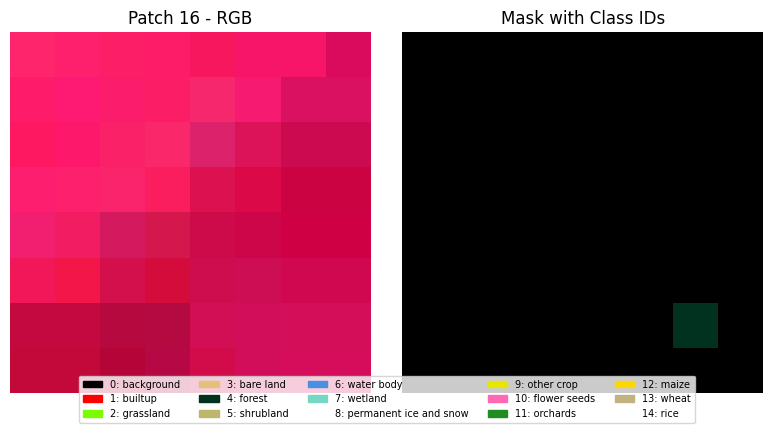

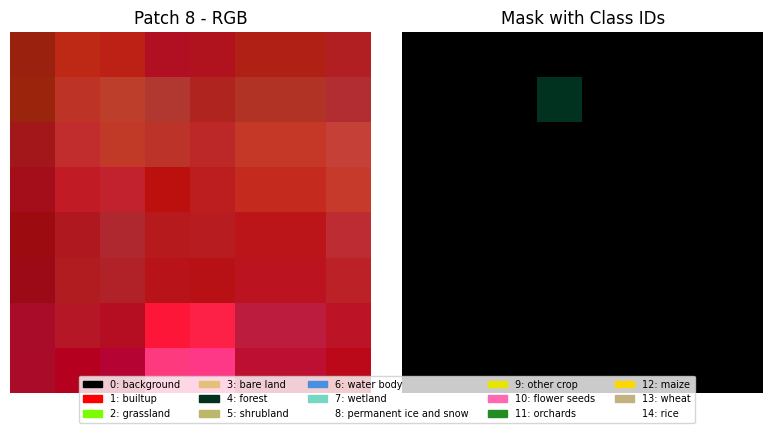

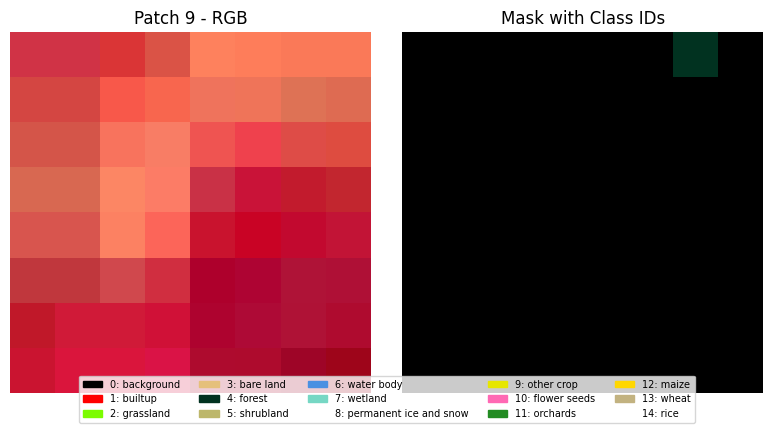

In [50]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import tifffile as tiff

# === Paths ===
out_img_dir  = "/content/drive/MyDrive/Patch8/Images"
out_mask_dir = "/content/drive/MyDrive/Patch8/Masks"

# === Class definitions & colormap ===
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]

color_map = {
    0:  '#000000', 1:  '#ff0000', 2:  '#7CFC00', 3:  '#e5c07b',
    4:  '#013220', 5:  '#BDB76B', 6:  '#4a90e2', 7:  '#76d7c4',
    8:  '#ffffff', 9:  '#e6e600', 10: '#ff69b4', 11: '#228B22',
    12: '#ffd700', 13: '#c2b280', 14: '#ffffff',
}

# build a ListedColormap from color_map
cmap = mcolors.ListedColormap([color_map[i] for i, _ in classes_with_ids])
bounds = list(color_map.keys()) + [max(color_map.keys()) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# === Pick 3 random patches ===
mask_files = sorted(os.listdir(out_mask_dir))
sample_masks = random.sample(mask_files, 3)

for fname in sample_masks:
    patch_id = os.path.splitext(fname)[0]

    img_patch = tiff.imread(os.path.join(out_img_dir, fname.replace(".tif", ".tif")))
    msk_patch = tiff.imread(os.path.join(out_mask_dir, fname))

    # Normalize image for RGB display (bands 4,3,2 if available, else first 3)
    if img_patch.ndim == 3 and img_patch.shape[2] >= 4:
        rgb = img_patch[..., [3, 2, 1]]
    else:
        rgb = img_patch[..., :3]
    rgb = (rgb - np.min(rgb)) / (np.ptp(rgb) + 1e-6)

    # Prepare figure
    fig, axs = plt.subplots(1, 2, figsize=(8,4))

    axs[0].imshow(rgb)
    axs[0].set_title(f"Patch {patch_id} - RGB")
    axs[0].axis("off")

    # Mask with custom colormap (ensures 0=black)
    axs[1].imshow(msk_patch, cmap=cmap, norm=norm)
    axs[1].set_title("Mask with Class IDs")
    axs[1].axis("off")

    # Legend
    handles = [mpatches.Patch(color=color_map[i], label=f"{i}: {name}")
               for i, name in classes_with_ids]
    fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=7, bbox_to_anchor=(0.5, -0.05))

    plt.tight_layout()
    plt.show()


Patchin all

In [51]:
import os
import numpy as np
import tifffile as tiff
from tqdm import tqdm

# === Input folders (all full images & masks) ===
image_dir = "/content/drive/MyDrive/Images"
mask_dir  = "/content/drive/MyDrive/Raster_masks_all"

# === Output folders ===
out_img_dir  = "/content/drive/MyDrive/Patch8/Images"
out_mask_dir = "/content/drive/MyDrive/Patch8/Masks"
os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_mask_dir, exist_ok=True)

# === Parameters ===
patch_size = 8
stride = patch_size   # you can change to overlap patches
patch_id = 1

# === Process each pair ===
for fname in sorted(os.listdir(image_dir)):
    if not fname.endswith(".tif"):
        continue

    image_path = os.path.join(image_dir, fname)
    mask_path  = os.path.join(mask_dir, fname)

    if not os.path.exists(mask_path):
        print(f"⚠️ Skipping {fname}, no matching mask found.")
        continue

    print(f"\n Processing {fname} ...")

    # Load image & mask
    image = tiff.imread(image_path).astype(np.float32)   # (H, W, C)
    mask  = tiff.imread(mask_path).astype(np.uint8)      # (H, W)
    H, W = mask.shape

    def extract_patch(y, x):
        img_patch = image[y:y+patch_size, x:x+patch_size, :]
        msk_patch = mask[y:y+patch_size, x:x+patch_size]
        return img_patch, msk_patch

    def is_valid(msk_patch):
        classes = np.unique(msk_patch)
        non_zero = [c for c in classes if c != 0]
        return len(non_zero) == 1, non_zero

    total_patches = (H // patch_size) * (W // patch_size)

    with tqdm(total=total_patches, desc=f"Extracting {fname}", ncols=100) as pbar:
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):

                img_patch, msk_patch = extract_patch(y, x)

                if img_patch.shape[0] != patch_size or img_patch.shape[1] != patch_size:
                    pbar.update(1)
                    continue

                if np.all(msk_patch == 0):  # skip background-only
                    pbar.update(1)
                    continue

                valid, non_zero = is_valid(msk_patch)

                if not valid:
                    found = False
                    for dy, dx in [(-1,0), (1,0), (0,-1), (0,1)]:
                        ny, nx = y+dy, x+dx
                        if ny < 0 or nx < 0 or ny+patch_size>H or nx+patch_size>W:
                            continue
                        img_patch, msk_patch = extract_patch(ny, nx)
                        valid, non_zero = is_valid(msk_patch)
                        if valid:
                            found = True
                            break
                    if not found:
                        pbar.update(1)
                        continue

                # Save patch
                img_out = os.path.join(out_img_dir, f"{patch_id}.tif")
                msk_out = os.path.join(out_mask_dir, f"{patch_id}.tif")
                tiff.imwrite(img_out, img_patch.astype(np.float32))
                tiff.imwrite(msk_out, msk_patch.astype(np.uint8))
                patch_id += 1

                pbar.update(1)

print(f"\n  Finished. Total patches saved: {patch_id-1}")



 Processing BM01_01.tif ...


Extracting BM01_01.tif: 100%|████████████████████████████| 746496/746496 [00:21<00:00, 34894.41it/s]



 Processing BM01_02.tif ...


Extracting BM01_02.tif: 100%|████████████████████████████| 746496/746496 [00:13<00:00, 53735.15it/s]



 Processing BM01_03.tif ...


...


 Processing BM66_05.tif ...


Extracting BM66_05.tif: 100%|███████████████████████████| 746496/746496 [00:04<00:00, 155000.67it/s]



 Processing BM66_07.tif ...


Extracting BM66_07.tif: 100%|███████████████████████████| 423360/423360 [00:02<00:00, 157612.34it/s]


  Finished. Total patches saved: 4500


In [52]:
import os
import numpy as np
import tifffile as tiff

# === Path to patched masks ===
out_mask_dir = "/content/drive/MyDrive/Patch8/Masks"

all_classes = set()

# Loop over all patch masks
for fname in os.listdir(out_mask_dir):
    if not fname.endswith(".tif"):
        continue
    mask = tiff.imread(os.path.join(out_mask_dir, fname))
    classes = np.unique(mask)
    all_classes.update(classes.tolist())

print(" Classes present in all patched masks:", sorted(all_classes))


 Classes present in all patched masks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


In [53]:
import os
import numpy as np
import tifffile as tiff
from sklearn.model_selection import train_test_split

# === Paths ===
out_img_dir  = "/content/drive/MyDrive/Patch8/Images"
out_mask_dir = "/content/drive/MyDrive/Patch8/Masks"

# === Collect all patch file names ===
img_files = sorted([f for f in os.listdir(out_img_dir) if f.endswith(".tif")])
msk_files = sorted([f for f in os.listdir(out_mask_dir) if f.endswith(".tif")])

assert len(img_files) == len(msk_files), "Mismatch between images and masks!"
print(f"Total patches found: {len(img_files)}")

# === Split into train (70%), val (20%), test (10%) ===
train_imgs, test_imgs, train_msks, test_msks = train_test_split(
    img_files, msk_files, test_size=0.30, random_state=42
)
val_imgs, test_imgs, val_msks, test_msks = train_test_split(
    test_imgs, test_msks, test_size=1/3, random_state=42
)

print(f"Training patches:   {len(train_imgs)}")
print(f"Validation patches: {len(val_imgs)}")
print(f"Test patches:       {len(test_imgs)}")

# === Load into arrays ===
def load_patches(img_list, msk_list):
    X, Y = [], []
    for imf, msf in zip(img_list, msk_list):
        img = tiff.imread(os.path.join(out_img_dir, imf)).astype(np.float32)
        msk = tiff.imread(os.path.join(out_mask_dir, msf)).astype(np.uint8)
        X.append(img)
        Y.append(msk)
    return np.array(X), np.array(Y)

X_train, Y_train = load_patches(train_imgs, train_msks)
X_val, Y_val     = load_patches(val_imgs, val_msks)
X_test, Y_test   = load_patches(test_imgs, test_msks)

# === Print dataset shapes ===
print("\nDataset shapes:")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val:  ", X_val.shape,   "Y_val:  ", Y_val.shape)
print("X_test: ", X_test.shape,  "Y_test: ", Y_test.shape)


Total patches found: 4500
Training patches:   3150
Validation patches: 900
Test patches:       450

Dataset shapes:
X_train: (3150, 8, 8, 23) Y_train: (3150, 8, 8)
X_val:   (900, 8, 8, 23) Y_val:   (900, 8, 8)
X_test:  (450, 8, 8, 23) Y_test:  (450, 8, 8)


In [54]:
np.save("/content/drive/MyDrive/Patch8/X_train", X_train)
np.save("/content/drive/MyDrive/Patch8/Y_train", Y_train)
np.save("/content/drive/MyDrive/Patch8/X_val", X_val)
np.save("/content/drive/MyDrive/Patch8/Y_val", Y_val)
np.save("/content/drive/MyDrive/Patch8/X_test", X_test)
np.save("/content/drive/MyDrive/Patch8/Y_test", Y_test)

In [7]:
X_train = np.load("/content/drive/MyDrive/Patch8/X_train.npy")
Y_train = np.load("/content/drive/MyDrive/Patch8/Y_train.npy")
X_val = np.load("/content/drive/MyDrive/Patch8/X_val.npy")
Y_val = np.load("/content/drive/MyDrive/Patch8/Y_val.npy")
X_test = np.load("/content/drive/MyDrive/Patch8/X_test.npy")
Y_test = np.load("/content/drive/MyDrive/Patch8/Y_test.npy")

In [8]:
print(X_train.shape)
print(Y_train.shape)
print(Y_train.dtype)
print(np.unique(Y_train))

(3150, 8, 8, 23)
(3150, 8, 8)
uint8
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [9]:
Y_train2 = []

for i in range(Y_train.shape[0]) :
  Y_train2.append(np.unique(Y_train[i])[1])

In [10]:
import numpy as np

Y_train2_array = np.array(Y_train2).reshape(-1, 1)  #Converting to 2D
np.save('Y_train2_array.npy', Y_train2_array)
print(Y_train2_array.shape)

(3150, 1)


In [11]:
Y_val2 = []

for i in range(Y_val.shape[0]) :
  Y_val2.append(np.unique(Y_val[i])[1])

  Y_test2 = []

for i in range(Y_test.shape[0]) :
  Y_test2.append(np.unique(Y_test[i])[1])

In [12]:
import numpy as np

Y_val2_array = np.array(Y_val2).reshape(-1, 1)  #Converting to 2D
np.save('Y_val2_array.npy', Y_val2_array)
print(Y_val2_array.shape)


Y_test2_array = np.array(Y_test2).reshape(-1, 1)  #Converting to 2D
np.save('Y_test2_array.npy', Y_test2_array)
print(Y_test2_array.shape)

(900, 1)
(450, 1)


In [13]:
print("Label shape:", Y_val2_array.shape)
print("Label dtype:", Y_val2_array.dtype)
print("Unique values:", np.unique(Y_val2_array))

Label shape: (900, 1)
Label dtype: uint8
Unique values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


# **Extra**

In [9]:
import numpy as np
import rasterio

# Load and clean the mask
with rasterio.open('/content/drive/MyDrive/OrgRaster/BM09_01.tif') as src:
    mask = src.read(1)
    profile = src.profile

# Replace 2147483647 with 0
mask = np.where(mask == 2147483647, 0, mask)

# Confirm fix
print("Classes after cleaning:", np.unique(mask))


Classes after cleaning: [0 1 2 3 4 5 6 7]


In [10]:
import os
import numpy as np
import rasterio
from tqdm.notebook import tqdm  # Use tqdm for live progress bar in Colab

# === Paths ===
input_folder = '/content/drive/MyDrive/OrgRaster'
output_folder = '/content/drive/MyDrive/Cleaned_Masks'

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Get all .tif files in input folder
mask_files = [f for f in os.listdir(input_folder) if f.endswith('.tif')]

# === Process each mask with progress bar ===
for filename in tqdm(mask_files, desc=" Cleaning masks"):
    input_path = os.path.join(input_folder, filename)
    output_path = os.path.join(output_folder, filename)

    with rasterio.open(input_path) as src:
        mask = src.read(1)
        profile = src.profile

    # Replace 2147483647 with 0 (background)
    mask_clean = np.where(mask == 2147483647, 0, mask)

    # Save cleaned mask
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(mask_clean, 1)


 Cleaning masks:   0%|          | 0/142 [00:00<?, ?it/s]

 Image shape: (6912, 6912)
 Mask shape:  (248, 265)
 Shape mismatch!


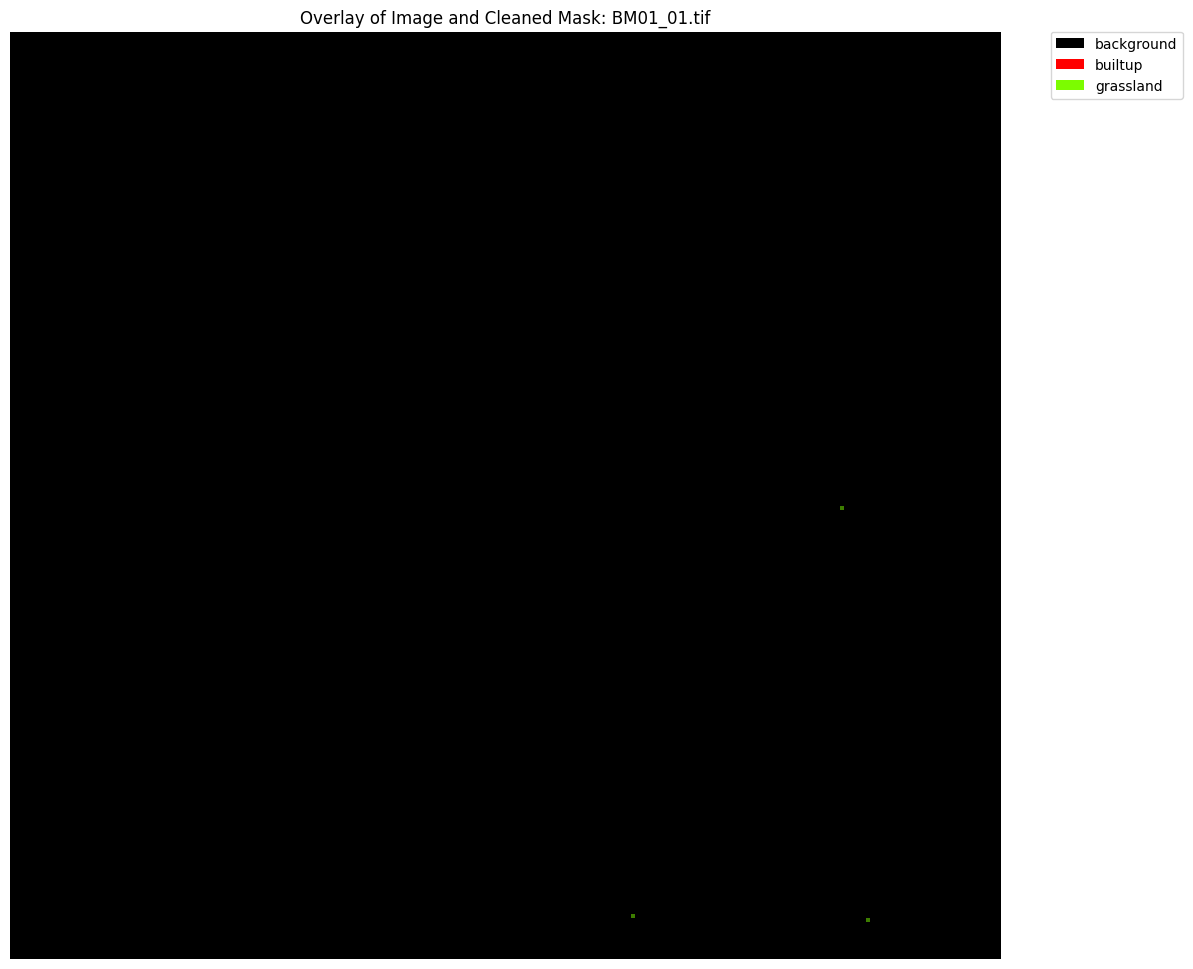

In [11]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# === CLASS DEFINITIONS ===
classes_with_ids = [
    (0, 'background'),
    (1, 'builtup'),
    (2, 'grassland'),
    (3, 'bare land'),
    (4, 'forest'),
    (5, 'shrubland'),
    (6, 'water body'),
    (7, 'wetland'),
    (8, 'permanent ice and snow'),
    (9, 'other crop'),
    (10, 'flower seeds'),
    (11, 'orchards'),
    (12, 'maize'),
    (13, 'wheat'),
    (14, 'rice')
]

color_map = {
    0:  '#000000',
    1:  '#ff0000',
    2:  '#7CFC00',
    3:  '#e5c07b',
    4:  '#013220',
    5:  '#BDB76B',
    6:  '#4a90e2',
    7:  '#76d7c4',
    8:  '#ffffff',
    9:  '#e6e600',
    10: '#ff69b4',
    11: '#228B22',
    12: '#ffd700',
    13: '#c2b280',
    14: '#ffffff',
}

# === Paths ===
image_folder = '/content/drive/MyDrive/Images'
mask_folder = '/content/drive/MyDrive/Cleaned_Masks'

# Pick one sample
sample_filename = next((f for f in os.listdir(mask_folder) if f.endswith('.tif')), None)

image_path = os.path.join(image_folder, sample_filename)
mask_path = os.path.join(mask_folder, sample_filename)

# === Read image ===
with rasterio.open(image_path) as img_src:
    image = img_src.read(1)
    img_shape = image.shape

# === Read cleaned mask ===
with rasterio.open(mask_path) as mask_src:
    mask = mask_src.read(1)
    mask_shape = mask.shape

# === Check shape
print(f" Image shape: {img_shape}")
print(f" Mask shape:  {mask_shape}")
if img_shape == mask_shape:
    print(" Shapes match.")
else:
    print(" Shape mismatch!")

# === Prepare colormap for visualization
# Get only used class IDs
used_classes = sorted(np.unique(mask))
cmap_colors = [color_map.get(cls, '#000000') for cls in used_classes]
cmap = ListedColormap(cmap_colors)

# Prepare legend
legend_elements = [
    Patch(facecolor=color_map[cls], label=label)
    for cls, label in classes_with_ids if cls in used_classes
]

# === Visualization
plt.figure(figsize=(12, 12))
plt.imshow(image, cmap='gray')
plt.imshow(np.ma.masked_where(mask == 0, mask), cmap=cmap, alpha=0.5)
plt.title(f"Overlay of Image and Cleaned Mask: {sample_filename}")
plt.axis('off')
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()


In [13]:
import rasterio
print(rasterio.open("/content/drive/MyDrive/OrgRaster/BM01_06.tif").transform)


| 0.00, 0.00, 106.62|
| 0.00,-0.00, 32.28|
| 0.00, 0.00, 1.00|


In [25]:
import os
import numpy as np
import rasterio
from tqdm import tqdm

image_dir = '/content/drive/MyDrive/Images'
mask_dir  = '/content/drive/MyDrive/Cleaned_Masks'
output_dir = '/content/drive/MyDrive/Padded_Masks'
os.makedirs(output_dir, exist_ok=True)

mask_files = [f for f in sorted(os.listdir(mask_dir)) if f.lower().endswith(('.tif', '.tiff'))]

for mask_file in tqdm(mask_files, desc='Aligning Masks', ncols=100):
    mask_path = os.path.join(mask_dir, mask_file)
    image_path = os.path.join(image_dir, mask_file)

    if not os.path.exists(image_path):
        print(f"Skipping {mask_file} — no matching image.")
        continue

    # === Load reference image (size + transform)
    with rasterio.open(image_path) as img_src:
        img_shape = (img_src.height, img_src.width)
        img_meta = img_src.meta.copy()
        img_transform = img_src.transform

    # === Load mask (values + transform)
    with rasterio.open(mask_path) as mask_src:
        mask = mask_src.read(1)
        mask_transform = mask_src.transform
        mask_meta = mask_src.meta.copy()

    # === Create empty padded mask same size as image
    padded_mask = np.zeros(img_shape, dtype=np.uint8)

    # === Calculate row/col offset of mask relative to image
    row_off = int((mask_transform.c - img_transform.c) / img_transform.a)
    col_off = int((mask_transform.f - img_transform.f) / img_transform.e)

    h, w = mask.shape

    # === Paste mask into correct location
    padded_mask[row_off:row_off+h, col_off:col_off+w] = mask

    # === Save new aligned mask
    mask_meta.update({
        'height': img_shape[0],
        'width': img_shape[1],
        'transform': img_transform,
        'crs': img_meta['crs'],
        'dtype': 'uint8',
        'count': 1
    })

    out_path = os.path.join(output_dir, mask_file)
    with rasterio.open(out_path, 'w', **mask_meta) as dst:
        dst.write(padded_mask, 1)

print(" All masks aligned with their images.")


Padding Masks:  78%|███████████████████████████████████▉          | 111/142 [00:10<00:02, 12.20it/s]

Skipping BM29_02 (1).tif — matching image not found.


Padding Masks:  86%|███████████████████████████████████████▌      | 122/142 [00:11<00:01, 12.75it/s]

Skipping BM32_03.tif — matching image not found.
Skipping BM32_04.tif — matching image not found.


Padding Masks: 100%|██████████████████████████████████████████████| 142/142 [00:12<00:00, 11.27it/s]

All masks have been padded and saved.


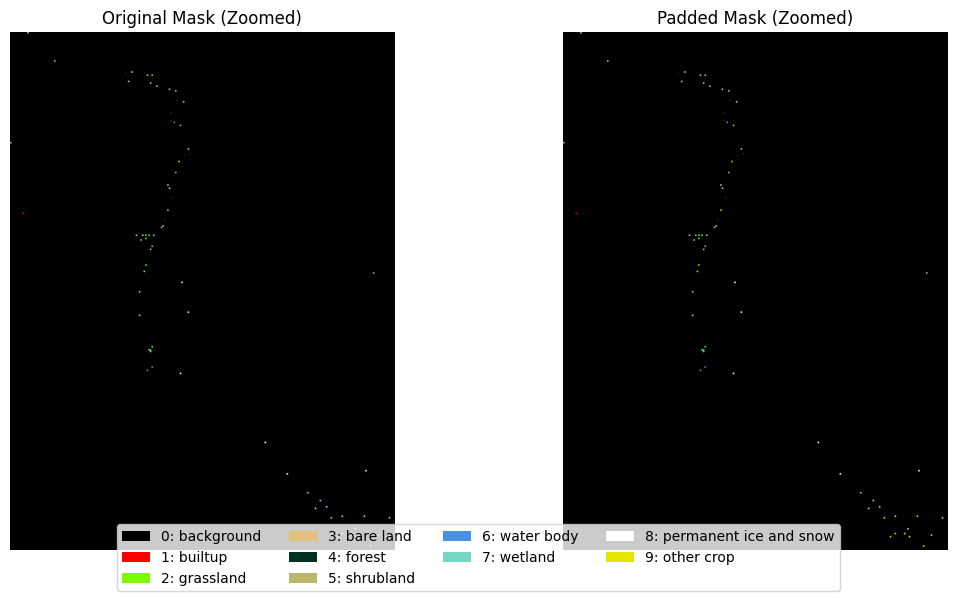

Original Mask Shape: (331, 246)
Image Shape:          (5405, 6912)
Padded Mask Shape:    (5405, 6912)
Original Classes:     [0 1 2 3 4 5 6 7 8 9]
Padded Classes:       [0 1 2 3 4 5 6 7 8 9]


In [8]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# === CLASS DEFINITIONS ===
classes_with_ids = [
    (0, 'background'),
    (1, 'builtup'),
    (2, 'grassland'),
    (3, 'bare land'),
    (4, 'forest'),
    (5, 'shrubland'),
    (6, 'water body'),
    (7, 'wetland'),
    (8, 'permanent ice and snow'),
    (9, 'other crop'),
    (10, 'flower seeds'),
    (11, 'orchards'),
    (12, 'maize'),
    (13, 'wheat'),
    (14, 'rice')
]

color_map = {
    0:  '#000000',
    1:  '#ff0000',
    2:  '#7CFC00',
    3:  '#e5c07b',
    4:  '#013220',
    5:  '#BDB76B',
    6:  '#4a90e2',
    7:  '#76d7c4',
    8:  '#ffffff',
    9:  '#e6e600',
    10: '#ff69b4',
    11: '#228B22',
    12: '#ffd700',
    13: '#c2b280',
    14: '#ffffff',
}

# === SELECT A SAMPLE MASK AND IMAGE ===
image_path = '/content/drive/MyDrive/Images/BM26_03.tif'
original_mask_path = '/content/drive/MyDrive/CleanedMasks/BM26_03.tif'
padded_mask_path = '/content/drive/MyDrive/PaddedMasks/BM26_03.tif'

# === LOAD DATA ===
with rasterio.open(original_mask_path) as src:
    original_mask = src.read(1)

with rasterio.open(padded_mask_path) as src:
    padded_mask = src.read(1)

with rasterio.open(image_path) as src:
    image = src.read(1)
    img_shape = image.shape

# === FIND BOUNDING BOX OF NON-BACKGROUND AREA ===
def find_nonzero_bbox(mask):
    y, x = np.where(mask != 0)
    if len(x) == 0 or len(y) == 0:
        return None
    minx, maxx = x.min(), x.max()
    miny, maxy = y.min(), y.max()
    return miny, maxy, minx, maxx

bbox = find_nonzero_bbox(original_mask)
if bbox:
    miny, maxy, minx, maxx = bbox
    crop_original = original_mask[miny:maxy, minx:maxx]
    crop_padded = padded_mask[miny:maxy, minx:maxx]
else:
    print("No non-zero classes found.")
    crop_original = original_mask
    crop_padded = padded_mask

# === VISUALIZATION ===
# Create color list and colormap
unique_classes = np.unique(np.concatenate([crop_original, crop_padded]))
unique_classes = [c for c in unique_classes if c in color_map]

cmap_vals = [color_map[c] for c in unique_classes]
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(cmap_vals)
bounds = list(range(len(unique_classes) + 1))
norm = BoundaryNorm(bounds, cmap.N)

# Legend
legend_elements = [Patch(facecolor=color_map[c], label=f"{c}: {name}")
                   for c, name in classes_with_ids if c in unique_classes]

# Plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(crop_original, cmap=cmap, norm=norm)
plt.title("Original Mask (Zoomed)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(crop_padded, cmap=cmap, norm=norm)
plt.title("Padded Mask (Zoomed)")
plt.axis('off')

plt.figlegend(handles=legend_elements, loc='lower center', ncol=4, frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# === DEBUG INFO ===
print("Original Mask Shape:", original_mask.shape)
print("Image Shape:         ", img_shape)
print("Padded Mask Shape:   ", padded_mask.shape)
print("Original Classes:    ", np.unique(original_mask))
print("Padded Classes:      ", np.unique(padded_mask))


# **Patching**

Single Image Patching

In [ ]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window
from tqdm import tqdm

# === CONFIGURATION ===
tile_size = 64
image_path = '/content/drive/MyDrive/Images/BM11_02.tif'
mask_path = '/content/drive/MyDrive/Correctedcleaned/BM11_02.tif'
output_image_dir = '/content/drive/MyDrive/example/images'
output_mask_dir = '/content/drive/MyDrive/example/masks'

# === Create output folders ===
os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

# === TILE GENERATION ===
tile_counter = 1
skipped_counter = 0

with rasterio.open(image_path) as img_ds, rasterio.open(mask_path) as mask_ds:
    height, width = img_ds.height, img_ds.width
    print(f"Image size: {height}x{width}. Starting tiling...")

    for i in tqdm(range(0, height, tile_size), desc="Processing rows"):
        for j in range(0, width, tile_size):
            if i + tile_size > height or j + tile_size > width:
                continue

            window = Window(j, i, tile_size, tile_size)

            # Read image and mask tiles
            img_tile = img_ds.read(window=window)  # shape: (23, 64, 64)
            mask_tile = mask_ds.read(1, window=window)  # shape: (64, 64)

            if mask_tile.shape != (tile_size, tile_size) or img_tile.shape[1:] != (tile_size, tile_size):
                continue

            # Skip tiles where image is fully black (all bands = 0)
            if np.all(img_tile == 0):
                skipped_counter += 1
                continue

            # Skip tiles where mask is all background (all 0s)
            if np.all(mask_tile == 0):
                skipped_counter += 1
                continue

            # === Save image tile (.tif) ===
            img_output_path = os.path.join(output_image_dir, f'{tile_counter}.tif')
            with rasterio.open(
                img_output_path,
                'w',
                driver='GTiff',
                height=tile_size,
                width=tile_size,
                count=img_tile.shape[0],
                dtype=img_tile.dtype
            ) as dst:
                dst.write(img_tile)

            # === Save raw mask tile (.tif) ===
            mask_output_path = os.path.join(output_mask_dir, f'{tile_counter}.tif')
            mask_meta = mask_ds.meta.copy()
            mask_meta.update({
                'height': tile_size,
                'width': tile_size,
                'count': 1,
                'dtype': 'uint8',
                'driver': 'GTiff'
            })

            with rasterio.open(mask_output_path, 'w', **mask_meta) as dst:
                dst.write(mask_tile, 1)

            tile_counter += 1

# === Summary ===
saved = tile_counter - 1
print(f"\n Finished tiling.")
print(f" Saved patches: {saved}")
print(f" Skipped patches (black or empty): {skipped_counter}")


Image size: 6912x6720. Starting tiling...


Processing rows: 100%|██████████| 108/108 [02:16<00:00,  1.26s/it]


 Finished tiling.
 Saved patches: 66
 Skipped patches (black or empty): 11274


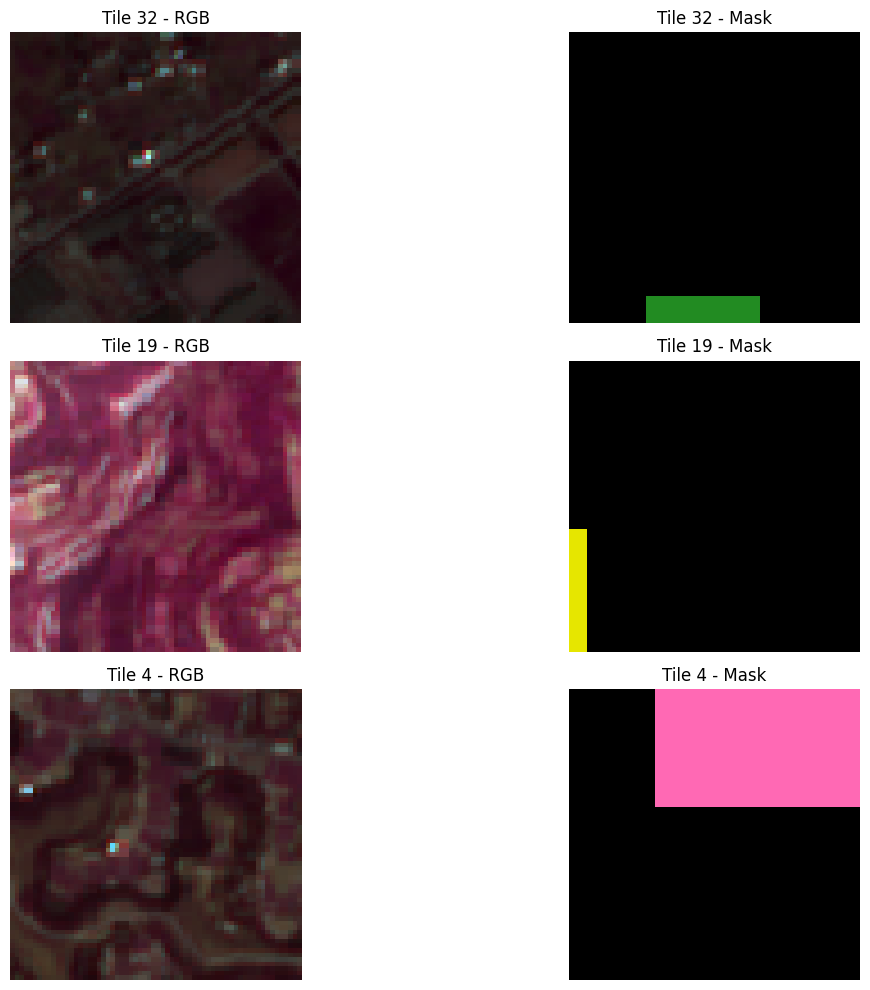

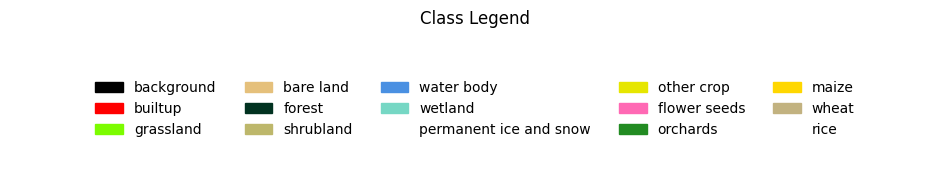

In [ ]:
import os
import numpy as np
import rasterio
from PIL import Image
import matplotlib.pyplot as plt
import random
import matplotlib.patches as mpatches

# === CLASS DEFINITIONS ===
classes_with_ids = [
    (0, 'background'),
    (1, 'builtup'),
    (2, 'grassland'),
    (3, 'bare land'),
    (4, 'forest'),
    (5, 'shrubland'),
    (6, 'water body'),
    (7, 'wetland'),
    (8, 'permanent ice and snow'),
    (9, 'other crop'),
    (10, 'flower seeds'),
    (11, 'orchards'),
    (12, 'maize'),
    (13, 'wheat'),
    (14, 'rice')
]

color_map = {
    0:  '#000000',
    1:  '#ff0000',
    2:  '#7CFC00',
    3:  '#e5c07b',
    4:  '#013220',
    5:  '#BDB76B',
    6:  '#4a90e2',
    7:  '#76d7c4',
    8:  '#ffffff',
    9:  '#e6e600',
    10: '#ff69b4',
    11: '#228B22',
    12: '#ffd700',
    13: '#c2b280',
    14: '#ffffff',
}

# === CONFIG ===
image_dir = '/content/drive/MyDrive/example/images'
mask_dir = '/content/drive/MyDrive/example/masks'

# === Only include tiles that have both image and mask ===
image_ids = {f.split('.')[0] for f in os.listdir(image_dir) if f.endswith('.tif')}
mask_ids = {f.split('.')[0] for f in os.listdir(mask_dir) if f.endswith('.tif')}
valid_ids = sorted(list(image_ids & mask_ids))
random_tiles = random.sample(valid_ids, min(3, len(valid_ids)))

# === Helpers ===
def hex_to_rgb(hex_color):
    h = hex_color.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

# Convert hex color_map to RGB tuple
color_map_rgb = {k: hex_to_rgb(v) for k, v in color_map.items()}

def stretch_contrast(image, gamma=1.0):
    norm = (image - image.min()) / (image.max() - image.min() + 1e-6)
    gamma_corrected = np.power(norm, gamma)
    return (gamma_corrected * 255).astype(np.uint8)

def colorize_mask(mask_array):
    color_mask = np.zeros((mask_array.shape[0], mask_array.shape[1], 3), dtype=np.uint8)
    for cls_id, rgb in color_map_rgb.items():
        color_mask[mask_array == cls_id] = rgb
    return color_mask

def plot_tile(tile_id, index):
    image_path = os.path.join(image_dir, f"{tile_id}.tif")
    mask_path = os.path.join(mask_dir, f"{tile_id}.tif")

    # Load RGB image
    with rasterio.open(image_path) as src:
        bands = [4, 3, 2]  # Assuming 4,3,2 are RGB (1-based indexing)
        bands = [b for b in bands if b <= src.count]
        img = src.read(bands)  # shape: (3, H, W)
        img = np.transpose(img, (1, 2, 0))  # to (H, W, C)
        img = stretch_contrast(img, gamma=0.8)

    # Load mask and convert to color
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
        color_mask = colorize_mask(mask)

    # Plot image
    plt.subplot(3, 2, index * 2 + 1)
    plt.imshow(img)
    plt.title(f"Tile {tile_id} - RGB")
    plt.axis('off')

    # Plot mask
    plt.subplot(3, 2, index * 2 + 2)
    plt.imshow(color_mask)
    plt.title(f"Tile {tile_id} - Mask")
    plt.axis('off')

# === Plot 3 random tiles ===
plt.figure(figsize=(14, 10))
for idx, tile_id in enumerate(random_tiles):
    plot_tile(tile_id, idx)
plt.tight_layout()
plt.show()

# === Class legend ===
legend_patches = [
    mpatches.Patch(color=color_map[class_id], label=label)
    for class_id, label in classes_with_ids
]
plt.figure(figsize=(12, 2))
plt.legend(handles=legend_patches, loc='center', ncol=5, frameon=False)
plt.axis('off')
plt.title("Class Legend")
plt.show()


In [ ]:
import os
import numpy as np
import rasterio

# === CONFIG ===
mask_dir = '/content/drive/MyDrive/example/masks'

# === Collect unique values ===
all_unique_values = set()

# Loop through each .tif mask
for fname in os.listdir(mask_dir):
    if fname.endswith('.tif'):
        path = os.path.join(mask_dir, fname)
        try:
            with rasterio.open(path) as src:
                mask = src.read(1)
                unique_vals = np.unique(mask)
                all_unique_values.update(unique_vals)
        except Exception as e:
            print(f"Error reading {fname}: {e}")

# === Display ===
final_unique = sorted(list(all_unique_values))
print("Unique mask values across all tiles:", final_unique)


Unique mask values across all tiles: [np.uint8(0), np.uint8(4), np.uint8(14)]


Patching all data

In [ ]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window
from tqdm import tqdm

# === CONFIGURATION ===
tile_size = 64

image_root = '/content/drive/MyDrive/Images'
mask_root = '/content/drive/MyDrive/Correctedcleaned'

output_image_dir = '/content/drive/MyDrive/tiles/images'
output_mask_dir = '/content/drive/MyDrive/tiles/masks'

# Create output folders if they don't exist
os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

# Collect image-mask pairs based on matching filenames
image_files = sorted([f for f in os.listdir(image_root) if f.endswith('.tif')])

tile_counter = 1
total_skipped = 0
total_saved = 0

for image_file in tqdm(image_files, desc="Processing all image-mask pairs"):
    image_path = os.path.join(image_root, image_file)
    mask_path = os.path.join(mask_root, image_file)

    if not os.path.exists(mask_path):
        print(f"[!] Mask not found for: {image_file}. Skipping.")
        continue

    with rasterio.open(image_path) as img_ds, rasterio.open(mask_path) as mask_ds:
        height, width = img_ds.height, img_ds.width
        print(f"\n Tiling {image_file}: {height}x{width}")

        saved_for_this_file = 0
        skipped_for_this_file = 0

        for i in range(0, height, tile_size):
            for j in range(0, width, tile_size):
                if i + tile_size > height or j + tile_size > width:
                    continue

                window = Window(j, i, tile_size, tile_size)

                img_tile = img_ds.read(window=window)  # (bands, 64, 64)
                mask_tile = mask_ds.read(1, window=window)  # (64, 64)

                if mask_tile.shape != (tile_size, tile_size) or img_tile.shape[1:] != (tile_size, tile_size):
                    skipped_for_this_file += 1
                    continue

                if np.all(img_tile == 0):
                    skipped_for_this_file += 1
                    continue

                if np.all(mask_tile == 0):
                    skipped_for_this_file += 1
                    continue

                # Save image tile
                img_out_path = os.path.join(output_image_dir, f'{tile_counter}.tif')
                with rasterio.open(
                    img_out_path,
                    'w',
                    driver='GTiff',
                    height=tile_size,
                    width=tile_size,
                    count=img_tile.shape[0],
                    dtype=img_tile.dtype
                ) as dst:
                    dst.write(img_tile)

                # Save raw mask tile
                mask_out_path = os.path.join(output_mask_dir, f'{tile_counter}.tif')
                mask_meta = mask_ds.meta.copy()
                mask_meta.update({
                    'height': tile_size,
                    'width': tile_size,
                    'count': 1,
                    'dtype': 'uint8',
                    'driver': 'GTiff'
                })

                with rasterio.open(mask_out_path, 'w', **mask_meta) as dst:
                    dst.write(mask_tile, 1)

                tile_counter += 1
                saved_for_this_file += 1

        print(f" Saved tiles: {saved_for_this_file} | ⛔ Skipped: {skipped_for_this_file}")
        total_saved += saved_for_this_file
        total_skipped += skipped_for_this_file

# === Final Summary ===
print("\n All tiling complete.")
print(f"Total saved patches: {total_saved}")
print(f"Total skipped patches: {total_skipped}")


Processing all image-mask pairs:   0%|          | 0/156 [00:00<?, ?it/s]


 Tiling BM01_01.tif: 6912x6912


Processing all image-mask pairs:   1%|          | 1/156 [01:59<5:09:09, 119.67s/it]

 Saved tiles: 19 | ⛔ Skipped: 11645

 Tiling BM01_02.tif: 6912x6912


Processing all image-mask pairs:   1%|▏         | 2/156 [03:59<5:07:10, 119.68s/it]

...

 Saved tiles: 55 | ⛔ Skipped: 11609

 Tiling BM66_05.tif: 6912x6912


Processing all image-mask pairs:  95%|█████████▍| 148/156 [3:11:37<09:28, 71.10s/it]

 Saved tiles: 15 | ⛔ Skipped: 11649

 Tiling BM66_07.tif: 3923x6912


Processing all image-mask pairs: 100%|██████████| 156/156 [3:12:18<00:00, 73.96s/it]

 Saved tiles: 5 | ⛔ Skipped: 6583
[!] Mask not found for: BM66_09.tif. Skipping.
[!] Mask not found for: BM67_01.tif. Skipping.
[!] Mask not found for: BM67_02.tif. Skipping.
[!] Mask not found for: BM67_03.tif. Skipping.
[!] Mask not found for: BM67_04.tif. Skipping.
[!] Mask not found for: BM67_05.tif. Skipping.
[!] Mask not found for: BM67_06.tif. Skipping.

 All tiling complete.
Total saved patches: 5136
Total skipped patches: 1288753


In [ ]:
import rasterio
import numpy as np

# === File paths ===
image_path = '/content/drive/MyDrive/tiles/images/2230.tif'
mask_path = '/content/drive/MyDrive/tiles/masks/2230.tif'

# === Read image ===
with rasterio.open(image_path) as img_ds:
    image = img_ds.read()  # shape: (bands, height, width)
    image_shape = image.shape

# === Read mask ===
with rasterio.open(mask_path) as mask_ds:
    mask = mask_ds.read(1)  # read first band
    mask_shape = mask.shape
    mask_unique = np.unique(mask)

# === Output ===
print(f"Image shape: {image_shape}")  # (bands, height, width)
print(f"Mask shape: {mask_shape}")    # (height, width)
print(f"Unique values in mask: {mask_unique}")


Image shape: (23, 64, 64)
Mask shape: (64, 64)
Unique values in mask: [ 0 13]


In [11]:
import os
import numpy as np
import rasterio
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# === Paths ===
image_dir = '/content/drive/MyDrive/tiles/images'
mask_dir = '/content/drive/MyDrive/tiles/masks'

# === Load tile IDs ===
tile_ids = sorted([
    os.path.splitext(f)[0]
    for f in os.listdir(image_dir)
    if f.endswith('.tif') and os.path.exists(os.path.join(mask_dir, f))
])

print(f"Total tiles found: {len(tile_ids)}")

# === Shuffle and split IDs ===
train_ids, temp_ids = train_test_split(tile_ids, test_size=0.3, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=1/3, random_state=42)

print(f"Train IDs: {len(train_ids)}")
print(f"Val IDs: {len(val_ids)}")
print(f"Test IDs: {len(test_ids)}")

def load_tiles(tile_list, desc):
    X, Y = [], []
    for tile_id in tqdm(tile_list, desc=desc):
        image_path = os.path.join(image_dir, f'{tile_id}.tif')
        mask_path = os.path.join(mask_dir, f'{tile_id}.tif')

        with rasterio.open(image_path) as img_src:
            image = img_src.read()  # (bands, 64, 64)
        with rasterio.open(mask_path) as mask_src:
            mask = mask_src.read(1)  # (64, 64)

        X.append(image)
        Y.append(mask)

    return np.array(X), np.array(Y)

# === Load splits with progress ===
X_train, Y_train = load_tiles(train_ids, "Loading Train")
X_val, Y_val = load_tiles(val_ids, "Loading Val")
X_test, Y_test = load_tiles(test_ids, "Loading Test")

# === Report Shapes ===
print("\n--- Split Summary ---")
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_val:   {X_val.shape}, Y_val:   {Y_val.shape}")
print(f"X_test:  {X_test.shape}, Y_test:  {Y_test.shape}")


Total tiles found: 5136
Train IDs: 3595
Val IDs: 1027
Test IDs: 514


Loading Test: 100%|██████████| 514/514 [06:12<00:00,  1.38it/s]



--- Split Summary ---
X_train: (3595, 23, 64, 64), Y_train: (3595, 64, 64)
X_val:   (1027, 23, 64, 64), Y_val:   (1027, 64, 64)
X_test:  (514, 23, 64, 64), Y_test:  (514, 64, 64)


In [12]:
np.save("/content/drive/MyDrive/tiles/X_train", X_train)
np.save("/content/drive/MyDrive/tiles/Y_train", Y_train)
np.save("/content/drive/MyDrive/tiles/X_val", X_val)
np.save("/content/drive/MyDrive/tiles/Y_val", Y_val)
np.save("/content/drive/MyDrive/tiles/X_test", X_test)
np.save("/content/drive/MyDrive/tiles/Y_test", Y_test)

In [55]:
X_train = np.load("/content/drive/MyDrive/tiles/X_train.npy")
Y_train = np.load("/content/drive/MyDrive/tiles/Y_train.npy")
X_val = np.load("/content/drive/MyDrive/tiles/X_val.npy")
Y_val = np.load("/content/drive/MyDrive/tiles/Y_val.npy")
X_test = np.load("/content/drive/MyDrive/tiles/X_test.npy")
Y_test = np.load("/content/drive/MyDrive/tiles/Y_test.npy")

In [56]:
# Change shape from (N, 23, 64, 64) -> (N, 64, 64, 23)
X_train = np.moveaxis(X_train, 1, -1)
X_val = np.moveaxis(X_val, 1, -1)
X_test = np.moveaxis(X_test, 1, -1)

# Confirm the change
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3595, 64, 64, 23)
X_val shape: (1027, 64, 64, 23)
X_test shape: (514, 64, 64, 23)


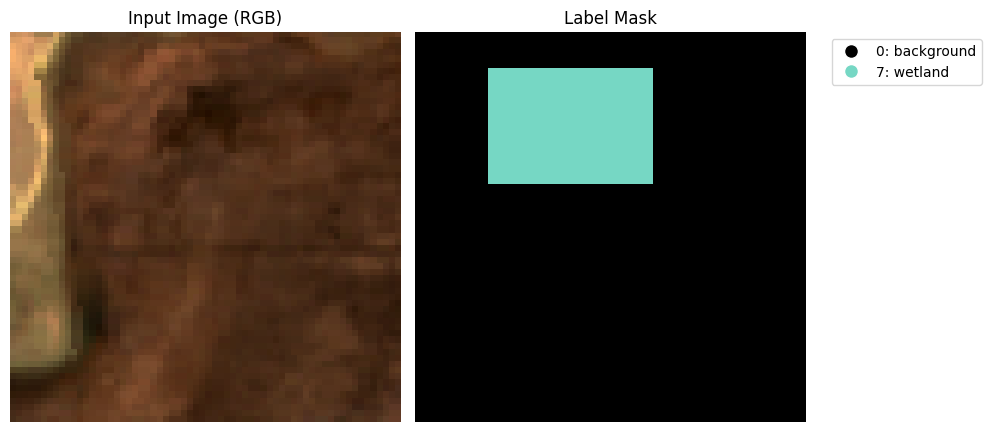

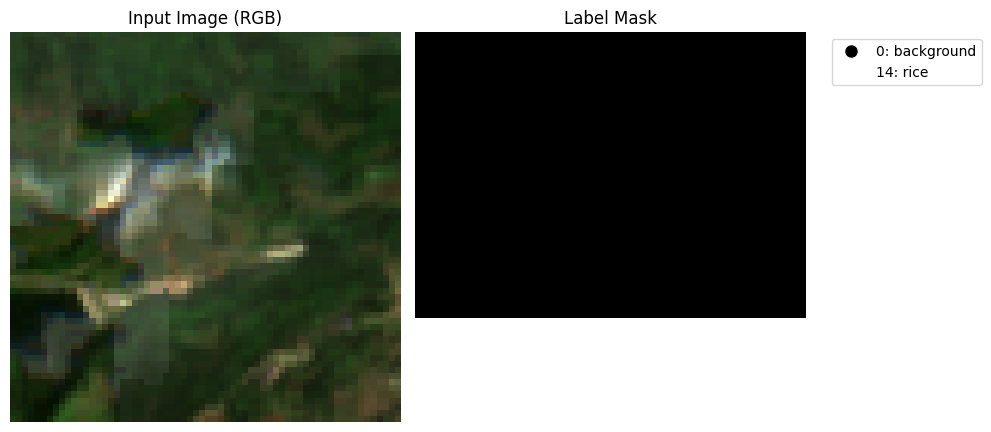

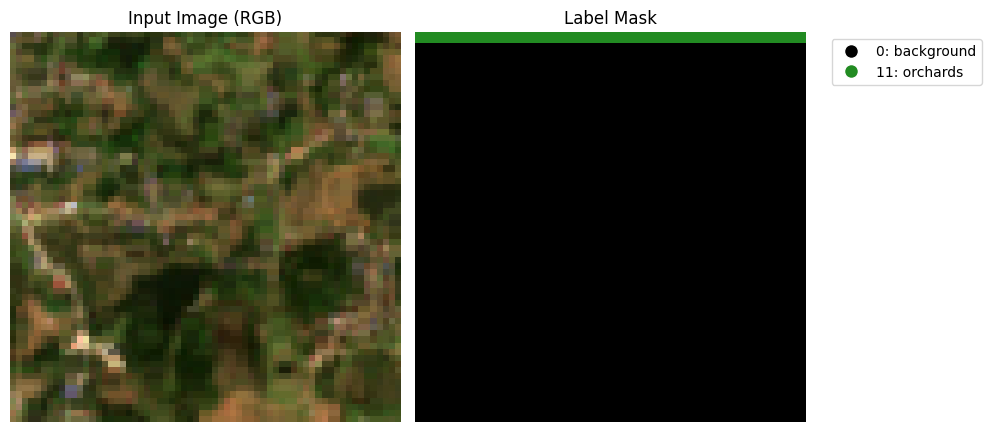

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import random

# === Class info ===
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]
label_map = dict(classes_with_ids)

color_map = {
    0:  '#000000', 1:  '#ff0000', 2:  '#7CFC00', 3:  '#e5c07b', 4:  '#013220',
    5:  '#BDB76B', 6:  '#4a90e2', 7:  '#76d7c4', 8:  '#ffffff', 9:  '#e6e600',
    10: '#ff69b4', 11: '#228B22', 12: '#ffd700', 13: '#c2b280', 14: '#ffffff'
}
color_map_rgb = {k: tuple(int(color_map[k].lstrip('#')[i:i+2], 16) for i in (0, 2 ,4)) for k in color_map}

# === Visualization ===
samples = random.sample(range(X_train.shape[0]), 3)

for idx in samples:
    image = X_train[idx]
    mask = Y_train[idx]

    # RGB band selection (assume bands 3, 2, 1 = RGB)
    rgb = image[:, :, [2, 1, 0]]
    rgb = (rgb - np.min(rgb)) / (np.max(rgb) - np.min(rgb))  # Normalize

    # Convert mask to RGB
    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls, color in color_map_rgb.items():
        color_mask[mask == cls] = color

    # === Plot ===
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(rgb)
    axes[0].set_title("Input Image (RGB)")
    axes[0].axis('off')

    axes[1].imshow(color_mask)
    axes[1].set_title("Label Mask")
    axes[1].axis('off')

    # Legend
    unique_classes = np.unique(mask)
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w',
                   label=f"{cls}: {label_map[cls]}",
                   markerfacecolor=np.array(color_map_rgb[cls])/255.0, markersize=10)
        for cls in unique_classes
    ]
    axes[1].legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


In [62]:
import numpy as np

# Assume X_train shape: (N, 64, 64, 23)
num_bands = X_train.shape[-1]

print("=== Per-Band Statistics ===")
for b in range(num_bands):
    band = X_train[:, :, :, b]
    print(f"Band {b+1:2d}: min={band.min():.4f}, max={band.max():.4f}, mean={band.mean():.4f}, std={band.std():.4f}")

=== Per-Band Statistics ===
Band  1: min=0.0000, max=1.8176, mean=0.1038, std=0.1854
Band  2: min=0.0000, max=1.7328, mean=0.1230, std=0.1767
Band  3: min=0.0000, max=1.6696, mean=0.1205, std=0.1729
Band  4: min=0.0000, max=1.6452, mean=0.1554, std=0.1646
Band  5: min=0.0000, max=1.6207, mean=0.2193, std=0.1493
Band  6: min=0.0000, max=1.5587, mean=0.2371, std=0.1422
Band  7: min=0.0000, max=1.5799, mean=0.2423, std=0.1406
Band  8: min=0.0000, max=1.5508, mean=0.2502, std=0.1340
Band  9: min=0.0000, max=1.1464, mean=0.1790, std=0.0710
Band 10: min=0.0000, max=1.0947, mean=0.1260, std=0.0604
Band 11: min=-35.7381, max=19.8625, mean=-16.3722, std=5.0950
Band 12: min=-30.1391, max=31.9491, mean=-9.6905, std=4.8647
Band 13: min=-401573.0625, max=116443.7188, mean=-0.1368, std=113.1671
Band 14: min=-871082.6875, max=4224218.0000, mean=2.0713, std=1165.5135
Band 15: min=-0.9899, max=0.9405, mean=0.4118, std=0.2423
Band 16: min=-8791260.0000, max=7079985.0000, mean=-0.2013, std=6172.7212
Band

In [63]:
import numpy as np

# Initialize normalized arrays
X_train_norm = np.zeros_like(X_train, dtype=np.float32)
X_val_norm   = np.zeros_like(X_val, dtype=np.float32)
X_test_norm  = np.zeros_like(X_test, dtype=np.float32)

print("=== Normalizing data using X_train min-max per band ===")
for b in range(X_train.shape[-1]):
    train_band = X_train[:, :, :, b]
    min_val = train_band.min()
    max_val = train_band.max()

    if max_val - min_val > 0:
        # Normalize train
        X_train_norm[:, :, :, b] = (train_band - min_val) / (max_val - min_val)
        # Normalize val using same stats
        X_val_norm[:, :, :, b] = (X_val[:, :, :, b] - min_val) / (max_val - min_val)
        # Normalize test using same stats
        X_test_norm[:, :, :, b] = (X_test[:, :, :, b] - min_val) / (max_val - min_val)
    else:
        X_train_norm[:, :, :, b] = 0.0
        X_val_norm[:, :, :, b] = 0.0
        X_test_norm[:, :, :, b] = 0.0

# Overwrite original variables (optional)
X_train = X_train_norm
X_val = X_val_norm
X_test = X_test_norm

print(" Normalization complete.")


=== Normalizing data using X_train min-max per band ===
 Normalization complete.


In [64]:
# Use the same min/max used for X_train normalization
train_min = X_train.min()
train_max = X_train.max()

X_val = (X_val - train_min) / (train_max - train_min)
X_val = np.clip(X_val, 0, 1)

X_test = (X_test - train_min) / (train_max - train_min)
X_test = np.clip(X_test, 0, 1)

In [65]:
import numpy as np

def check_normalization(name, X):
    print(f"=== {name} ===")
    print(f"Shape: {X.shape}")
    print(f"Min: {np.min(X):.4f}")
    print(f"Max: {np.max(X):.4f}")
    print(f"Mean: {np.mean(X):.4f}")
    print(f"Std Dev: {np.std(X):.4f}")
    print("-" * 30)

check_normalization("X_train", X_train)
check_normalization("X_val", X_val)
check_normalization("X_test", X_test)

=== X_train ===
Shape: (3595, 64, 64, 23)
Min: 0.0000
Max: 1.0000
Mean: 0.2706
Std Dev: 0.2461
------------------------------
=== X_val ===
Shape: (1027, 64, 64, 23)
Min: 0.0000
Max: 1.0000
Mean: 0.2737
Std Dev: 0.2481
------------------------------
=== X_test ===
Shape: (514, 64, 64, 23)
Min: 0.0000
Max: 1.0000
Mean: 0.2721
Std Dev: 0.2462
------------------------------


In [68]:
Y_train2 = []
for mask in Y_train:
    unique = np.unique(mask)
    non_zero = unique[unique != 0]
    if len(non_zero) > 0:
        Y_train2.append(non_zero[0])  # Take the first non-background class

In [69]:
import numpy as np

Y_train2_array = np.array(Y_train2).reshape(-1, 1)  #Converting to 2D
np.save('Y_train2_array.npy', Y_train2_array)
print(Y_train2_array.shape)

(3595, 1)


In [70]:
Y_val2 = []
for mask in Y_val:
    unique = np.unique(mask)
    non_zero = unique[unique != 0]
    if len(non_zero) > 0:
        Y_val2.append(non_zero[0])

Y_test2 = []
for mask in Y_test:
    unique = np.unique(mask)
    non_zero = unique[unique != 0]
    if len(non_zero) > 0:
        Y_test2.append(non_zero[0])

In [71]:
import numpy as np

Y_val2_array = np.array(Y_val2).reshape(-1, 1)  #Converting to 2D
np.save('Y_val2_array.npy', Y_val2_array)
print(Y_val2_array.shape)


Y_test2_array = np.array(Y_test2).reshape(-1, 1)  #Converting to 2D
np.save('Y_test2_array.npy', Y_test2_array)
print(Y_test2_array.shape)

(1027, 1)
(514, 1)


# **Tiles**

In [ ]:
import numpy as np
import tifffile as tiff
from glob import glob
import os
from collections import Counter
from tqdm import tqdm

input_mask_dir = "/content/drive/MyDrive/OrgRaster"
mask_files = sorted(glob(os.path.join(input_mask_dir, "*.tif")))

class_counter = Counter()

for msk_path in tqdm(mask_files, desc="Counting classes"):
    mask = tiff.imread(msk_path).astype(np.uint8)
    unique, counts = np.unique(mask, return_counts=True)
    class_counter.update(dict(zip(unique, counts)))

print("\nClass distribution across all masks:")
for cls, count in sorted(class_counter.items()):
    print(f"Class {cls}: {count} pixels")


In [16]:
import os
from glob import glob

# === Input Directories ===
image_dir = "/content/drive/MyDrive/Images"
mask_dir  = "/content/drive/MyDrive/PaddedMasks"

# === Get File Lists (only filenames, not full paths) ===
image_files = sorted([os.path.basename(f) for f in glob(os.path.join(image_dir, "*.tif"))])
mask_files  = sorted([os.path.basename(f) for f in glob(os.path.join(mask_dir, "*.tif"))])

# === Convert to sets for comparison ===
image_set = set(image_files)
mask_set  = set(mask_files)

# === Find mismatches ===
images_without_mask = sorted(list(image_set - mask_set))
masks_without_image = sorted(list(mask_set - image_set))

# === Print results ===
print("✅ Total Images:", len(image_files))
print("✅ Total Masks :", len(mask_files))

print("\n🚨 Images with NO matching mask:")
for f in images_without_mask:
    print("  ", f)

print("\n🚨 Masks with NO matching image:")
for f in masks_without_image:
    print("  ", f)


✅ Total Images: 139
✅ Total Masks : 139

🚨 Images with NO matching mask:

🚨 Masks with NO matching image:


In [58]:
import os
import numpy as np
import tifffile as tiff
from glob import glob
from tqdm import tqdm

# === Input and Output Paths ===
input_image_dir = "/content/drive/MyDrive/Images"
input_mask_dir  = "/content/drive/MyDrive/PaddedMasks"
output_image_dir = "/content/drive/MyDrive/Tiles8/Images"
output_mask_dir  = "/content/drive/MyDrive/Tiles8/Masks"

os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

# === Patch Parameters ===
patch_size = 8
patch_id = 1

# === Per-class patch limit ===
MAX_PATCHES_PER_CLASS = 400   # adjust this to reach ~4–5k total

# === Track saved patches per class ===
class_counts = {c: 0 for c in range(1, 15)}  # ignore background=0

# === Read File Lists ===
image_files = sorted(glob(os.path.join(input_image_dir, "*.tif")))
mask_files  = sorted(glob(os.path.join(input_mask_dir, "*.tif")))
assert len(image_files) == len(mask_files), "Mismatch between images and masks!"

# === Patch Extraction ===
def patch_and_save(img_path, msk_path):
    global patch_id

    image = tiff.imread(img_path).astype(np.float32)   # (H, W, C)
    image = np.clip(image, 0, 10000) / 10000.0         # normalize reflectance
    mask  = tiff.imread(msk_path).astype(np.uint8)     # (H, W)

    h, w = mask.shape

    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            img_patch = image[y:y+patch_size, x:x+patch_size, :]
            msk_patch = mask[y:y+patch_size, x:x+patch_size]

            # Skip incomplete patches
            if img_patch.shape[0] != patch_size or img_patch.shape[1] != patch_size:
                continue

            # Skip empty image patches
            if np.all(img_patch == 0):
                continue

            # Get non-zero classes inside the mask
            unique_classes = np.unique(msk_patch)
            non_zero_classes = [c for c in unique_classes if c != 0]

            # Save a separate patch for each non-zero class
            for cls in non_zero_classes:
                if class_counts[cls] >= MAX_PATCHES_PER_CLASS:
                    continue  # skip if class quota is full

                # Create a mask with only this class
                cls_mask = np.where(msk_patch == cls, cls, 0).astype(np.uint8)

                # Skip if class pixels are too few (<2 pixels)
                if np.sum(cls_mask == cls) < 2:
                    continue

                img_out = os.path.join(output_image_dir, f"{patch_id}.tif")
                msk_out = os.path.join(output_mask_dir,  f"{patch_id}.tif")

                # Save correctly (keep (H, W, C))
                tiff.imwrite(img_out, img_patch, photometric='minisblack')
                tiff.imwrite(msk_out, cls_mask)

                patch_id += 1
                class_counts[cls] += 1

# === Run Extraction ===
for img_path, msk_path in tqdm(zip(image_files, mask_files),
                               total=len(image_files),
                               desc="Extracting 8x8 Patches"):
    patch_and_save(img_path, msk_path)

print(f"\n Finished. Total patches saved: {patch_id - 1}")
print(" Per-class counts:")
print(class_counts)


Extracting 8x8 Patches: 100%|██████████| 139/139 [2:10:44<00:00, 56.44s/it]


 Finished. Total patches saved: 144
 Per-class counts:
{1: 11, 2: 28, 3: 23, 4: 13, 5: 19, 6: 17, 7: 4, 8: 1, 9: 17, 10: 4, 11: 2, 12: 5, 13: 0, 14: 0}


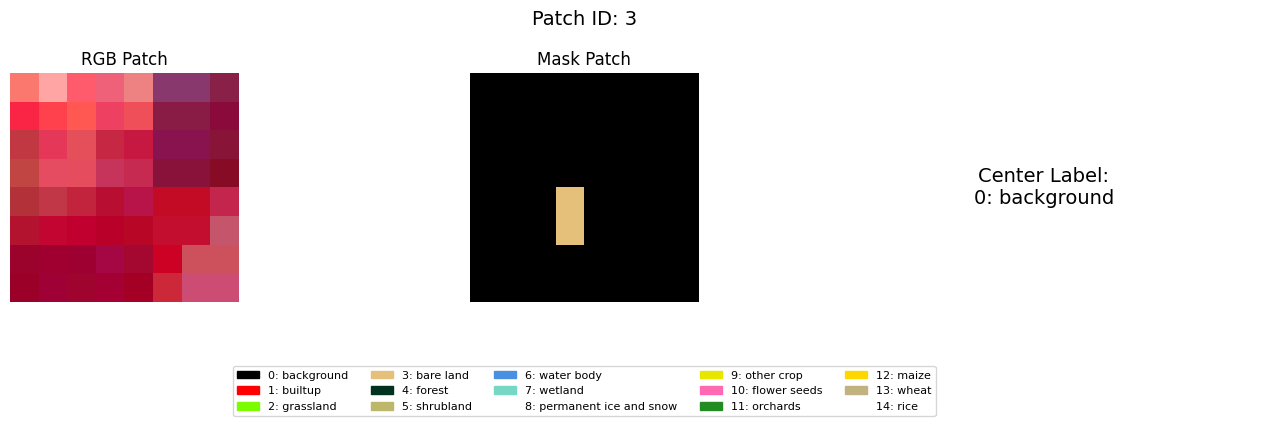

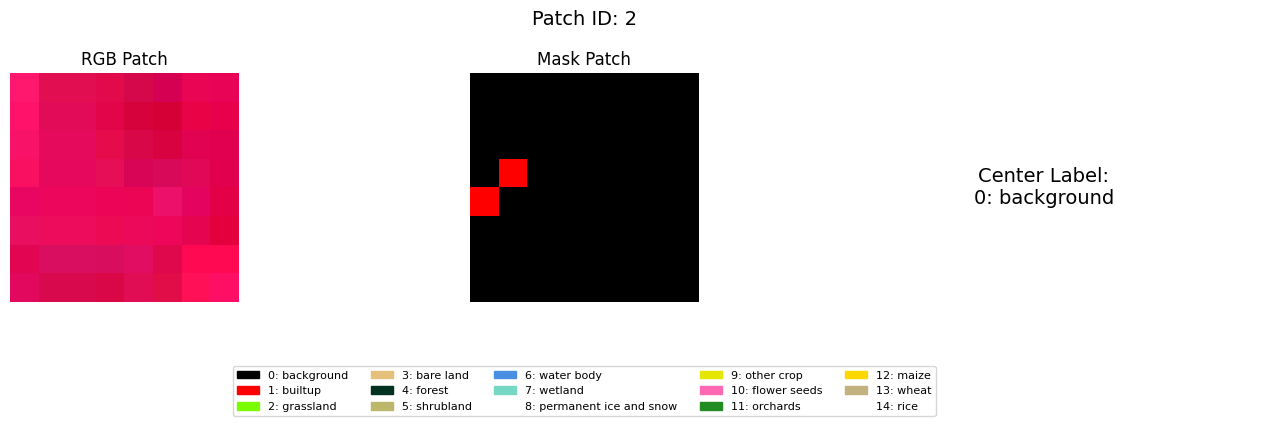

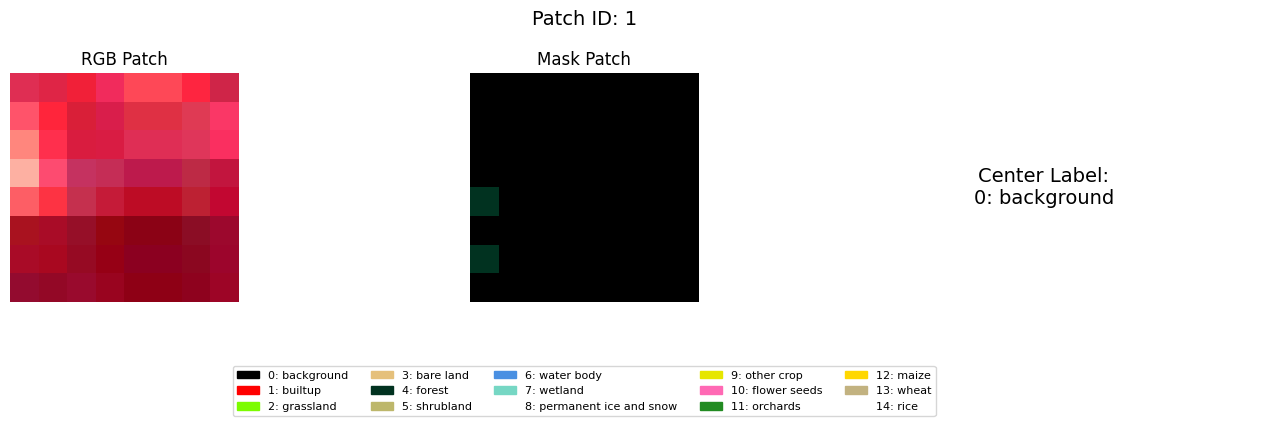

In [56]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import tifffile as tiff
from glob import glob

# === Class and Color Maps ===
label_map = {
    'background': 0,
    'builtup': 1,
    'grassland' : 2,
    'bare land': 3,
    'forest': 4,
    'shrubland': 5,
    'water body': 6,
    'wetland': 7,
    'permanent ice and snow': 8,
    'other crop': 9,
    'flower seeds': 10,
    'orchards' : 11,
    'maize': 12,
    'wheat': 13,
    'rice': 14,
}

# Reverse map: ID → Class name
reverse_label_map = {v: k for k, v in label_map.items()}

# Color map keyed by class ID
color_map = {
    0:  '#000000',
    1:  '#ff0000',
    2:  '#7CFC00',
    3:  '#e5c07b',
    4:  '#013220',
    5:  '#BDB76B',
    6:  '#4a90e2',
    7:  '#76d7c4',
    8:  '#ffffff',
    9:  '#e6e600',
    10: '#ff69b4',
    11: '#228B22',
    12: '#ffd700',
    13: '#c2b280',
    14: '#ffffff',
}

# === Directories ===
image_dir = "/content/drive/MyDrive/Tiles8/Images"
mask_dir  = "/content/drive/MyDrive/Tiles8/Masks"

# === File Lists ===
image_files = sorted(glob(os.path.join(image_dir, "*.tif")))
mask_files  = sorted(glob(os.path.join(mask_dir, "*.tif")))

assert len(image_files) == len(mask_files), "Mismatch between images and masks count!"

# === Build matplotlib colormap from hex ===
hex_colors = [color_map[i] for i in range(15)]
rgb_colors = [tuple(int(h[j:j+2], 16) / 255 for j in (1, 3, 5)) for h in hex_colors]
custom_cmap = ListedColormap(rgb_colors)

# === Pick and plot 3 random patches ===
for idx in random.sample(range(len(image_files)), 3):
    img = tiff.imread(image_files[idx])   # shape: (H, W, bands)
    msk = tiff.imread(mask_files[idx])    # shape: (H, W)

    # True-color RGB (Sentinel-like: use bands 4,3,2 if available)
    # Sentinel-2 true color (Red=3, Green=2, Blue=1) in 0-based indexing
    if img.shape[2] >= 4:
        rgb = img[..., [3, 2, 1]].astype(np.float32)
    else:
       rgb = img[..., :3].astype(np.float32)

# Contrast stretch using percentiles
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)


    center_label = int(msk[msk.shape[0] // 2, msk.shape[1] // 2])
    patch_id = os.path.basename(image_files[idx]).split('.')[0]

    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(14, 4))

    axs[0].imshow(rgb)
    axs[0].set_title("RGB Patch")
    axs[0].axis("off")

    axs[1].imshow(msk, cmap=custom_cmap, vmin=0, vmax=14)
    axs[1].set_title("Mask Patch")
    axs[1].axis("off")

    axs[2].text(0.5, 0.5, f"Center Label:\n{center_label}: {reverse_label_map.get(center_label, 'Unknown')}",
                fontsize=14, ha='center', va='center')
    axs[2].axis("off")

    # Legend (all 15 classes)
    handles = [mpatches.Patch(color=color_map[i], label=f"{i}: {reverse_label_map[i]}")
               for i in range(15)]
    fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f"Patch ID: {patch_id}", fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    plt.show()


In [45]:
import os
import numpy as np
import tifffile as tiff
from glob import glob

# === Path to masks ===
mask_dir = "/content/drive/MyDrive/Tiles8/Masks"

# === Collect all masks ===
mask_files = sorted(glob(os.path.join(mask_dir, "*.tif")))

# === Gather all unique classes across dataset ===
all_classes = set()
for msk_path in mask_files:
    mask = tiff.imread(msk_path)
    all_classes.update(np.unique(mask))

# === Print final result ===
print(sorted(all_classes))

[np.uint8(0), np.uint8(1), np.uint8(2)]


In [ ]:
import os
import numpy as np
import rasterio
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm  # <-- progress bar!

# === Paths ===
image_dir = "/content/drive/MyDrive/Patch8/Images"
mask_dir = "/content/drive/MyDrive/Patch8/Masks"

# === Get list of patch IDs ===
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".tif")])
patch_ids = [os.path.splitext(f)[0] for f in image_files]

# === Split IDs ===
train_ids, temp_ids = train_test_split(patch_ids, test_size=0.3, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=1/3, random_state=42)

print(f"Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")

# === Load patches with tqdm progress bar ===
def load_dataset(patch_ids, desc="Loading"):
    X = []
    Y = []
    for pid in tqdm(patch_ids, desc=desc):
        img_path = os.path.join(image_dir, f"{pid}.tif")
        mask_path = os.path.join(mask_dir, f"{pid}.tif")

        # Load image (23 bands)
        with rasterio.open(img_path) as src:
            img = src.read()  # (23, H, W)
            img = np.transpose(img, (1, 2, 0))  # → (H, W, 23)

        # Load mask (H, W)
        mask = np.array(Image.open(mask_path))

        X.append(img)
        Y.append(mask)

    return np.array(X), np.array(Y)

# === Load each split with live progress ===
X_train, Y_train = load_dataset(train_ids, desc="Loading Train")
X_val, Y_val = load_dataset(val_ids, desc="Loading Val")
X_test, Y_test = load_dataset(test_ids, desc="Loading Test")

print("\n Done! Shapes:")
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_val:   {X_val.shape}, Y_val:   {Y_val.shape}")
print(f"X_test:  {X_test.shape}, Y_test:  {Y_test.shape}")


In [ ]:
np.save("/content/drive/MyDrive/Tiles8/X_train", X_train)
np.save("/content/drive/MyDrive/Tiles8/Y_train", Y_train)
np.save("/content/drive/MyDrive/Tiles8/X_val", X_val)
np.save("/content/drive/MyDrive/Tiles8/Y_val", Y_val)
np.save("/content/drive/MyDrive/Tiles8/X_test", X_test)
np.save("/content/drive/MyDrive/Tiles8/Y_test", Y_test)

# **2D CNN**

In [76]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Flatten Y_train if it's (3595, 1) to (3595,)
y_train_flat = Y_train.flatten()

# Define unique classes (make sure to include all that appear in y)
classes = np.unique(y_train_flat)

# Compute weights
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_flat)

# Convert to dictionary
class_weights_dict = dict(zip(classes, class_weights))

In [73]:
from tensorflow.keras import layers, models

def build_simple_cnn(input_shape=(64, 64, 23), num_classes=15):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [81]:
# Normalize weights so max is 1
max_weight = max(class_weights_dict.values())
class_weights_dict = {cls: weight / max_weight for cls, weight in class_weights_dict.items()}

In [82]:
model = build_simple_cnn(input_shape=(64, 64, 23), num_classes=15)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train, Y_train2_array,
    validation_data=(X_val, Y_val2_array),
    epochs=50,
    batch_size=32,
    class_weight=class_weights_dict  # Optional, if you calculated class imbalance
)

# **Training Phase**

In [15]:
import tensorflow as tf
from tensorflow.keras import backend as K

def f1_score(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true = tf.cast(y_true, tf.float32)

    tp = K.sum(K.cast(y_true * y_pred, 'float'), axis=0)
    fp = K.sum(K.cast((1 - y_true) * y_pred, 'float'), axis=0)
    fn = K.sum(K.cast(y_true * (1 - y_pred), 'float'), axis=0)

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())

    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    f1 = tf.where(tf.math.is_nan(f1), tf.zeros_like(f1), f1)
    return K.mean(f1)

**Unet++**

In [34]:
import numpy as np
from collections import Counter

# Count class frequencies
class_counts = Counter(Y_train2_array)
total_samples = len(Y_train2_array)

print("Class Counts:")
for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

Class Counts:
Class 1: 247
Class 2: 53
Class 3: 212
Class 4: 669
Class 5: 97
Class 6: 275
Class 7: 234
Class 8: 193
Class 9: 441
Class 10: 387
Class 11: 368
Class 12: 66
Class 13: 202
Class 14: 151


In [33]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# Make sure Y_train2_array exists and is 1D: shape (n_samples,)
# If not, convert it:
Y_train2_array = np.array(Y_train2_array).flatten()

# === 1. Count frequencies of each class
class_counts = Counter(Y_train2_array)
total_samples = len(Y_train2_array)
num_classes = len(class_counts)

# === 2. Compute weights (inverse frequency)
class_weights = {}
for cls, count in class_counts.items():
    weight = total_samples / (num_classes * count)
    class_weights[cls] = round(weight, 4)

In [ ]:
# === 3. OPTIONAL: Scale max to 300
max_weight = 300
max_actual = max(class_weights.values())
scale = max_weight / max_actual
class_weights = {cls: round(w * scale, 4) for cls, w in class_weights.items()}

In [35]:
# === 4. Print summary
print(f"{'Class':<10} {'Samples':<10} {'Weight':<10}")
print("-" * 30)
for cls in sorted(class_counts):
    print(f"{cls:<10} {class_counts[cls]:<10} {class_weights[cls]:<10}")

Class      Samples    Weight    
------------------------------
1          247        1.0396    
2          53         4.845     
3          212        1.2113    
4          669        0.3838    
5          97         2.6473    
6          275        0.9338    
7          234        1.0974    
8          193        1.3305    
9          441        0.5823    
10         387        0.6635    
11         368        0.6978    
12         66         3.8907    
13         202        1.2712    
14         151        1.7006    


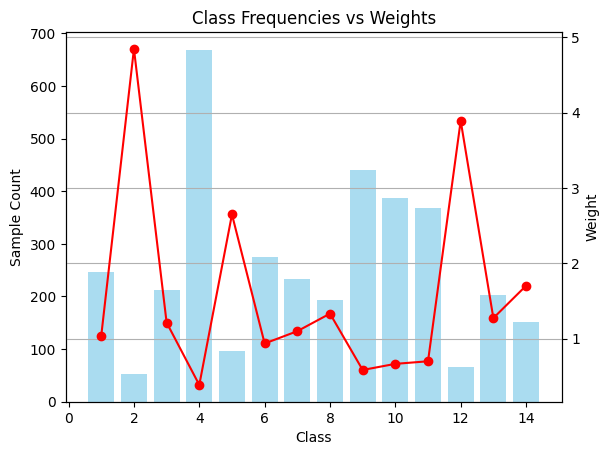

In [36]:
# === 5. OPTIONAL: Plot
labels = sorted(class_counts.keys())
counts = [class_counts[l] for l in labels]
weights = [class_weights[l] for l in labels]

fig, ax1 = plt.subplots()
ax1.bar(labels, counts, color='skyblue', alpha=0.7, label='Sample Count')
ax2 = ax1.twinx()
ax2.plot(labels, weights, color='red', marker='o', label='Weight')

ax1.set_xlabel('Class')
ax1.set_ylabel('Sample Count')
ax2.set_ylabel('Weight')
plt.title("Class Frequencies vs Weights")
plt.grid(True)
plt.show()

In [16]:
print("Unique classes in Y_train2_array:", np.unique(Y_train2_array))
print("Unique classes in Y_val2_array:", np.unique(Y_val2_array))
print("Unique classes in Y_test2_array:", np.unique(Y_test2_array))

Unique classes in Y_train2_array: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Unique classes in Y_val2_array: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Unique classes in Y_test2_array: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models
tf.compat.v1.enable_eager_execution()

def build_unetplusplus_classifier(input_shape=(8, 8, 23), num_classes=15):  # Changed to 15 classes
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x0_0 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x0_0 = layers.Conv2D(32, 3, activation='relu', padding='same')(x0_0)
    p0 = layers.MaxPooling2D(pool_size=(2, 2))(x0_0)

    x1_0 = layers.Conv2D(64, 3, activation='relu', padding='same')(p0)
    x1_0 = layers.Conv2D(64, 3, activation='relu', padding='same')(x1_0)
    p1 = layers.MaxPooling2D(pool_size=(2, 2))(x1_0)

    x2_0 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    x2_0 = layers.Conv2D(128, 3, activation='relu', padding='same')(x2_0)

    # Decoder - Dense skip connections
    x1_1 = layers.Concatenate()([x1_0, layers.UpSampling2D()(x2_0)])
    x1_1 = layers.Conv2D(64, 3, activation='relu', padding='same')(x1_1)
    x1_1 = layers.Conv2D(64, 3, activation='relu', padding='same')(x1_1)

    x0_1 = layers.Concatenate()([x0_0, layers.UpSampling2D()(x1_0)])
    x0_1 = layers.Conv2D(32, 3, activation='relu', padding='same')(x0_1)
    x0_1 = layers.Conv2D(32, 3, activation='relu', padding='same')(x0_1)

    x0_2 = layers.Concatenate()([x0_0, x0_1, layers.UpSampling2D()(x1_1)])
    x0_2 = layers.Conv2D(32, 3, activation='relu', padding='same')(x0_2)
    x0_2 = layers.Conv2D(32, 3, activation='relu', padding='same')(x0_2)

    # Classification head
    gap = layers.GlobalAveragePooling2D()(x0_2)
    output = layers.Dense(num_classes, activation='softmax')(gap)  # Fixed to 15 classes

    model = models.Model(inputs=inputs, outputs=output)
    return model


In [19]:
# Build and compile the model
model = build_unetplusplus_classifier()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
from tensorflow.keras.callbacks import ModelCheckpoint
import os
# Checkpoint for saving the weights"""
# path_dic_w =

save_dir = "/content/drive/MyDrive/Models/Unet"
os.makedirs(save_dir, exist_ok=True)

# Define the full path for the model file
checkpoint_path = os.path.join(save_dir, 'unetplus_epoch_{epoch:02d}.h5')

# Now you can safely use it in the callback
callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    save_best_only=False,
    monitor='val_loss',
    mode='min',
    verbose=1
)
# Create a callback that saves the model's weights at every epoch"""
callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=False,
                                                 save_best_only=False,
                                                 monitor="val_loss",
                                                 mode = "min",
                                                 verbose=1)

"""# Create a callback to reduce the learning rate using the ReduceLROnPlateau function"""
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                 factor=0.33,
                                                 patience=5,
                                                 mode="min")

early_stop =tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 25,
                          verbose = 1,
                          restore_best_weights = False)

"""# Compile the checkpoints and other settings as a callback"""
callback_list = [callback,reduce_lr,early_stop]

In [21]:
history = model.fit(
    X_train, Y_train2_array,
    validation_data=(X_val, Y_val2_array),
    epochs=80,
    batch_size=32,
    verbose=1
)


Epoch 1/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.2335 - loss: 3.4685 - val_accuracy: 0.1833 - val_loss: 2.2821
Epoch 2/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3240 - loss: 1.9033 - val_accuracy: 0.3622 - val_loss: 4.9476
Epoch 3/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4404 - loss: 4.3531 - val_accuracy: 0.4756 - val_loss: 2.4431
Epoch 4/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4981 - loss: 1.5794 - val_accuracy: 0.4689 - val_loss: 1.5985
Epoch 5/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5257 - loss: 1.4397 - val_accuracy: 0.5444 - val_loss: 1.4218
Epoch 6/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5927 - loss: 1.2980 - val_accuracy: 0.5667 - val_loss: 1.3676
Epoch 7/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6029 - loss: 1.2099 - val_accuracy: 0.5467 - val_loss: 1.3555
Epoch 8/80
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6054 - loss: 1.1939 - val_accuracy: 0.6100 - val_los

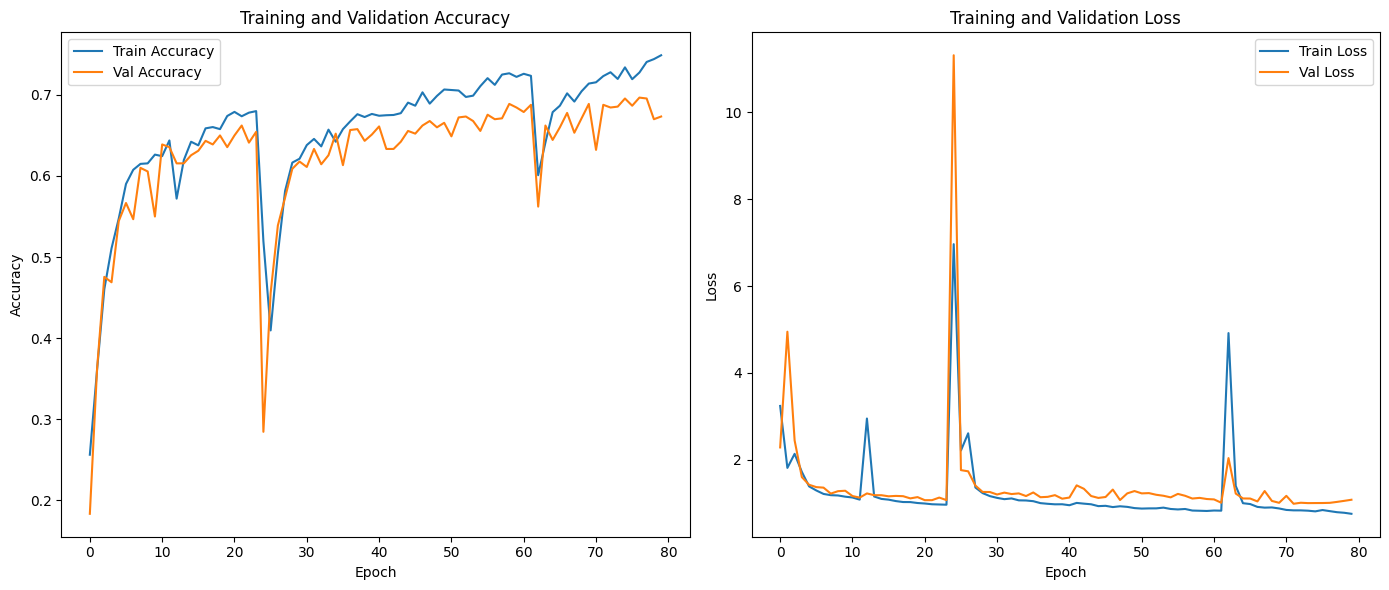

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# --- Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import numpy as np

# === 1. Predict class probabilities and convert to class labels ===
Y_pred_probs = model.predict(X_test)
Y_pred_labels = np.argmax(Y_pred_probs, axis=1)

# === 2. Ground truth labels (already in Y_test2_array) ===
Y_true = Y_test2_array.astype(int)  # ensure it's integer type

# === 3. Accuracy ===
acc = accuracy_score(Y_true, Y_pred_labels)

# === 4. F1-Score (macro and weighted) ===
f1_macro = f1_score(Y_true, Y_pred_labels, average='macro')
f1_weighted = f1_score(Y_true, Y_pred_labels, average='weighted')

# === 5. Cohen's Kappa ===
kappa = cohen_kappa_score(Y_true, Y_pred_labels)

# === 6. Loss on test set ===
loss_fn = SparseCategoricalCrossentropy()
test_loss = loss_fn(Y_true, Y_pred_probs).numpy()

# === 7. Print results ===
print(f" Accuracy        : {acc:.4f}")
print(f" F1 Score (macro): {f1_macro:.4f}")
print(f" F1 Score (weighted): {f1_weighted:.4f}")
print(f" Cohen's Kappa   : {kappa:.4f}")
print(f" Test Loss       : {test_loss:.4f}")


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step
 Accuracy        : 0.6378
 F1 Score (macro): 0.5413
 F1 Score (weighted): 0.6061
 Cohen's Kappa   : 0.5915
 Test Loss       : 1.2073


In [25]:
# Get predicted class probabilities (if model outputs softmax)
Y_pred_probs = model.predict(X_test)

# Convert to class IDs by taking argmax
Y_pred_array = np.argmax(Y_pred_probs, axis=1)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [27]:
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]
class_names = [label for _, label in classes_with_ids]

In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix
import pandas as pd

# === Class definitions ===
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]
class_ids   = [c[0] for c in classes_with_ids]
class_names = [c[1] for c in classes_with_ids]

# === Collapse Y_test masks into single labels per patch ===
Y_test_labels = np.array([np.max(msk) for msk in Y_test])  # (450,)

# === Confusion Matrix ===
cm = confusion_matrix(Y_test_labels, y_pred, labels=class_ids)

# === Accuracy metrics ===
UA = np.diag(cm) / (cm.sum(axis=0) + 1e-9)   # User's accuracy (precision)
PA = np.diag(cm) / (cm.sum(axis=1) + 1e-9)   # Producer's accuracy (recall)
OA = np.trace(cm) / np.sum(cm)               # Overall accuracy

# === Put into DataFrame ===
results_df = pd.DataFrame({
    "Class ID": class_ids,
    "Class Name": class_names,
    "User's Acc (Precision)": UA,
    "Producer's Acc (Recall)": PA,
    "Support (#True Patches)": cm.sum(axis=1)
})

print("\nConfusion Matrix (rows=True, cols=Pred):")
print(pd.DataFrame(cm, index=class_names, columns=class_names))

print("\nPer-Class Accuracy Table:")
print(results_df)

print("\nOverall Accuracy:", OA)



Confusion Matrix (rows=True, cols=Pred):
                        background  builtup  grassland  bare land  forest  \
background                       0        0          0          0       0   
builtup                          0       29          1          0       2   
grassland                        0        2          3          0       0   
bare land                        0        3          0         14       0   
forest                           0        0          0          0      79   
shrubland                        0        0          1          0       6   
water body                       0        1          0          1       0   
wetland                          0        0          0          3       0   
permanent ice and snow           0        0          0          1       0   
other crop                       0        5          1          0      14   
flower seeds                     0        0          0          0       3   
orchards                         0


Confusion Matrix (rows=True, cols=Pred):
                        background  builtup  grassland  bare land  forest  \
background                       0        0          0          0       0   
builtup                          0       29          1          0       2   
grassland                        0        2          3          0       0   
bare land                        0        3          0         14       0   
forest                           0        0          0          0      79   
shrubland                        0        0          1          0       6   
water body                       0        1          0          1       0   
wetland                          0        0          0          3       0   
permanent ice and snow           0        0          0          1       0   
other crop                       0        5          1          0      14   
flower seeds                     0        0          0          0       3   
orchards                         0

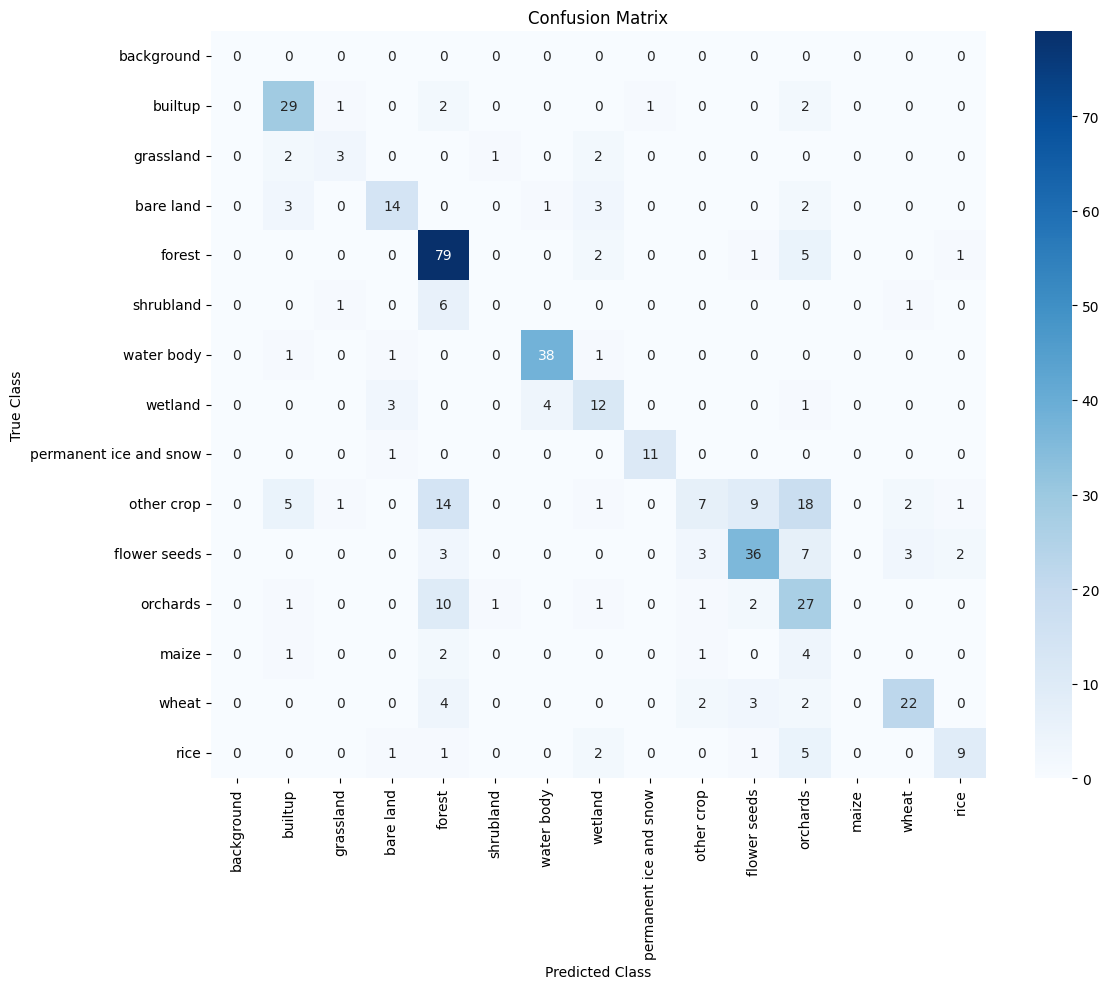

In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Class definitions ===
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]
class_ids   = [c[0] for c in classes_with_ids]
class_names = [c[1] for c in classes_with_ids]

# === Collapse Y_test masks into single labels per patch ===
Y_test_labels = np.array([np.max(msk) for msk in Y_test])  # (N,)

# === Confusion Matrix ===
cm = confusion_matrix(Y_test_labels, y_pred, labels=class_ids)

# === Accuracy metrics ===
UA = np.diag(cm) / (cm.sum(axis=0) + 1e-9)   # User's accuracy (precision)
PA = np.diag(cm) / (cm.sum(axis=1) + 1e-9)   # Producer's accuracy (recall)
OA = np.trace(cm) / np.sum(cm)               # Overall accuracy

# === Put into DataFrame ===
results_df = pd.DataFrame({
    "Class ID": class_ids,
    "Class Name": class_names,
    "User's Acc (Precision)": UA,
    "Producer's Acc (Recall)": PA,
    "Support (#True Patches)": cm.sum(axis=1)
})

print("\nConfusion Matrix (rows=True, cols=Pred):")
print(pd.DataFrame(cm, index=class_names, columns=class_names))

print("\nPer-Class Accuracy Table:")
print(results_df)

print("\nOverall Accuracy:", OA)

# === Plot confusion matrix heatmap ===
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()



Confusion Matrix (rows=True, cols=Pred):
                        background  builtup  grassland  bare land  forest  \
background                       0        0          0          0       0   
builtup                          0       29          1          0       2   
grassland                        0        2          3          0       0   
bare land                        0        3          0         14       0   
forest                           0        0          0          0      79   
shrubland                        0        0          1          0       6   
water body                       0        1          0          1       0   
wetland                          0        0          0          3       0   
permanent ice and snow           0        0          0          1       0   
other crop                       0        5          1          0      14   
flower seeds                     0        0          0          0       3   
orchards                         0

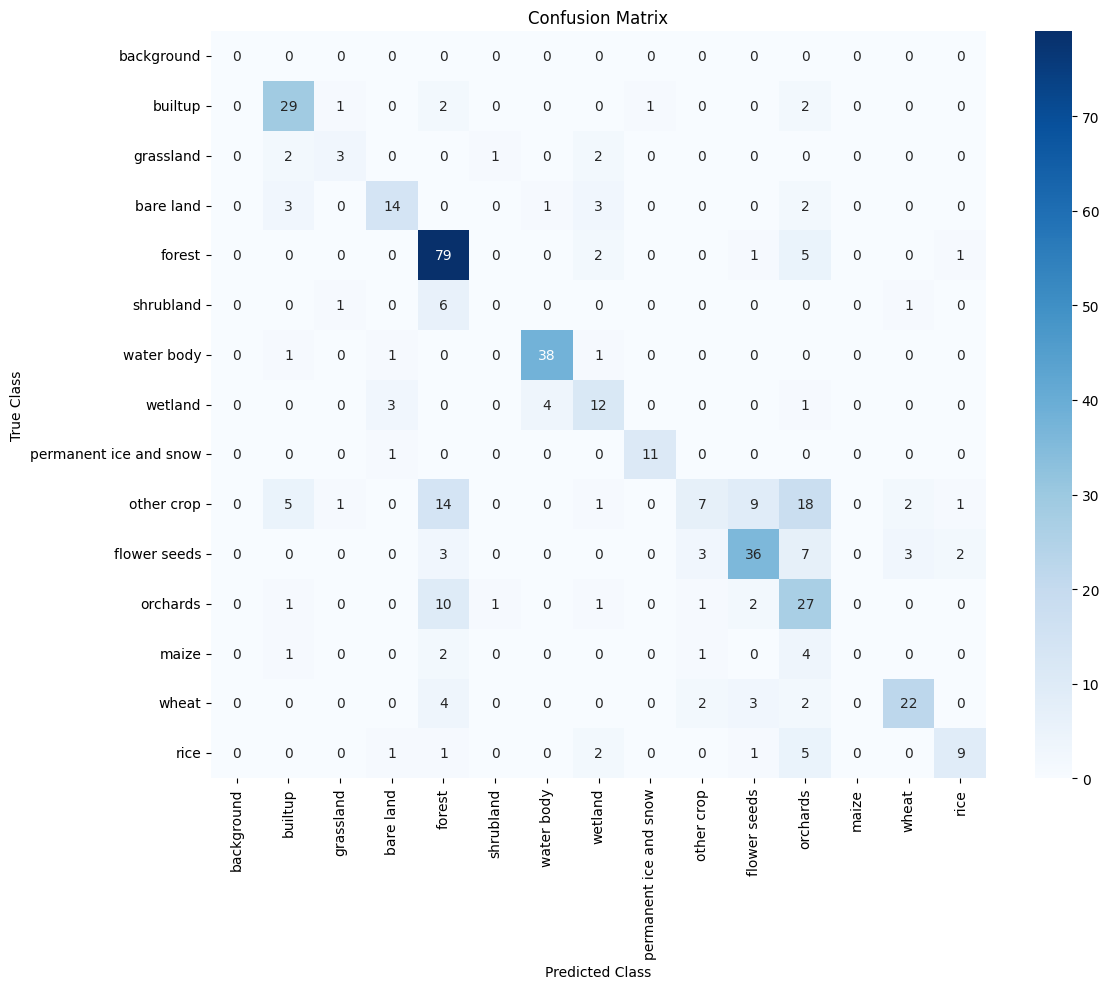

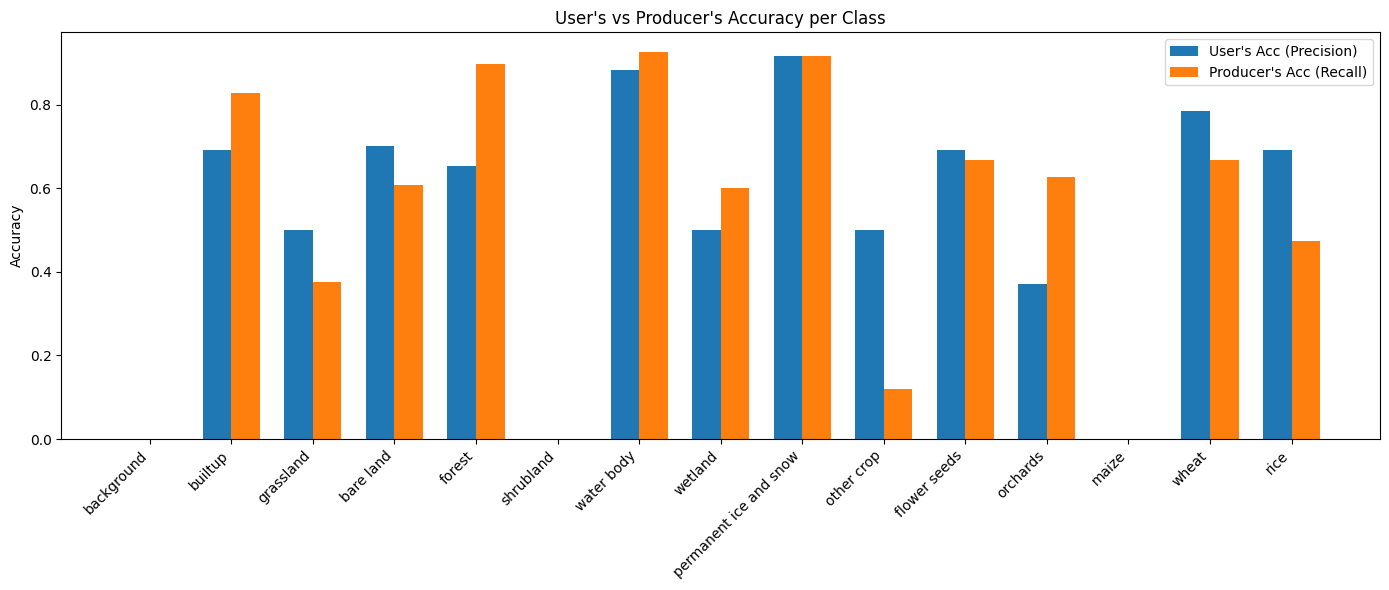

In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Class definitions ===
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]
class_ids   = [c[0] for c in classes_with_ids]
class_names = [c[1] for c in classes_with_ids]

# === Collapse Y_test masks into single labels per patch ===
# (each patch has only one class ID)
Y_test_labels = np.array([np.max(msk) for msk in Y_test])  # shape (N,)

# === Confusion Matrix ===
cm = confusion_matrix(Y_test_labels, y_pred, labels=class_ids)

# === Accuracy metrics ===
UA = np.diag(cm) / (cm.sum(axis=0) + 1e-9)   # User's accuracy (precision)
PA = np.diag(cm) / (cm.sum(axis=1) + 1e-9)   # Producer's accuracy (recall)
OA = np.trace(cm) / np.sum(cm)               # Overall accuracy

# === Results as DataFrame ===
results_df = pd.DataFrame({
    "Class ID": class_ids,
    "Class Name": class_names,
    "User's Acc (Precision)": UA,
    "Producer's Acc (Recall)": PA,
    "Support (#True Patches)": cm.sum(axis=1)
})

# === Print tables ===
print("\nConfusion Matrix (rows=True, cols=Pred):")
print(pd.DataFrame(cm, index=class_names, columns=class_names))

print("\nPer-Class Accuracy Table:")
print(results_df)

print("\nOverall Accuracy:", OA)

print("\nUser's Accuracy (per class):")
for cid, cname, ua in zip(class_ids, class_names, UA):
    print(f"{cid:2d} {cname:25s}: {ua:.3f}")

print("\nProducer's Accuracy (per class):")
for cid, cname, pa in zip(class_ids, class_names, PA):
    print(f"{cid:2d} {cname:25s}: {pa:.3f}")

# === Plot confusion matrix heatmap ===
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# === Plot UA & PA bar charts ===
x = np.arange(len(class_names))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, UA, width, label="User's Acc (Precision)")
plt.bar(x + width/2, PA, width, label="Producer's Acc (Recall)")
plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("User's vs Producer's Accuracy per Class")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import os
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from tqdm import tqdm

# === Paths ===
big_image_path = "/content/drive/MyDrive/Images/BM05_01.tif"

# === Load big image ===
big_img = tiff.imread(big_image_path).astype(np.float32)   # (H, W, 23)
H, W, C = big_img.shape
print("Big image shape:", big_img.shape)

patch_size = 8

# === Collect patches and coords ===
patches, coords = [], []
for y in range(0, H - patch_size + 1, patch_size):
    for x in range(0, W - patch_size + 1, patch_size):
        patch = big_img[y:y+patch_size, x:x+patch_size, :]
        if patch.shape == (patch_size, patch_size, C):
            patches.append(patch)
            coords.append((y, x))

patches = np.array(patches)   # (N, 8, 8, 23)
print("Total patches:", patches.shape[0])

# === Predict in batches ===
batch_size = 512
pred_labels = []

for i in tqdm(range(0, len(patches), batch_size), desc="Predicting", ncols=100):
    batch = patches[i:i+batch_size]
    preds = model.predict(batch, verbose=0)   # (batch, num_classes)
    cls = np.argmax(preds, axis=-1)           # (batch,)
    pred_labels.extend(cls)

pred_labels = np.array(pred_labels)

# === Reconstruct classification map ===
class_map = np.zeros((H, W), dtype=np.uint8)
for (y, x), cls in zip(coords, pred_labels):
    class_map[y:y+patch_size, x:x+patch_size] = cls

print("Classification map shape:", class_map.shape)

# === Define classes and color map ===
classes_with_ids = [
    (0, 'background'), (1, 'builtup'), (2, 'grassland'), (3, 'bare land'),
    (4, 'forest'), (5, 'shrubland'), (6, 'water body'), (7, 'wetland'),
    (8, 'permanent ice and snow'), (9, 'other crop'), (10, 'flower seeds'),
    (11, 'orchards'), (12, 'maize'), (13, 'wheat'), (14, 'rice')
]

color_map = {
    0:  '#000000', 1:  '#ff0000', 2:  '#7CFC00', 3:  '#e5c07b',
    4:  '#013220', 5:  '#BDB76B', 6:  '#4a90e2', 7:  '#76d7c4',
    8:  '#ffffff', 9:  '#e6e600', 10: '#ff69b4', 11: '#228B22',
    12: '#ffd700', 13: '#c2b280', 14: '#ffffff'
}

# Build colormap
cmap = mcolors.ListedColormap([color_map[i] for i, _ in classes_with_ids])
bounds = list(color_map.keys()) + [max(color_map.keys()) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# === Plot classification map ===
plt.figure(figsize=(10, 8))
plt.imshow(class_map, cmap=cmap, norm=norm)
plt.title("Classification Map")
plt.axis("off")

# Legend
handles = [mpatches.Patch(color=color_map[i], label=f"{i}: {name}")
           for i, name in classes_with_ids]
plt.legend(handles=handles, loc="lower center", ncol=5,
           fontsize=8, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

# === Unique classes present ===
unique_classes = np.unique(class_map)
print("Unique class IDs present:", unique_classes)


Big image shape: (6912, 6912, 23)
Total patches: 746496


Predicting:  69%|████████████████████████████████▎              | 1003/1458 [01:36<00:43, 10.42it/s]